In [1]:
%reload_ext autoreload
%autoreload 2

import numpy as np
from synphot import SpectralElement
from synphot.models import Empirical1D
import os, glob
import emcee
import dust
import progressbar
import sys
import astropy.units as u
import astropy.constants as const
import traceback
import pickle
from astropy.io import fits, ascii
from astropy.stats import sigma_clipped_stats as scs
from scipy import interpolate
from scipy.integrate import simpson
import matplotlib as mpl
import matplotlib.pyplot as plt
from astropy.io.misc.hdf5 import read_table_hdf5
import pandas as pd
import itertools
from tqdm import tqdm
import corner
import time
from scipy.stats import gaussian_kde
import torch
from sbi import utils as sbi_utils
from sbi.neural_nets import posterior_nn
from sbi import inference
from mcmc import mcmc
from mc_parallel import parallel_sed_fit
import sbi_pp

/Users/aswin/anaconda3/envs/synphot/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
nrc_filts = np.array(['F070W','F090W','F115W','F140M','F150W', 'F150W2', 'F162M',
                        'F164N','F182M','F187N','F200W','F210M','F212N','F250M',
                        'F277W','F300M','F322W2','F323N','F335M','F356W','F360M',
                        'F405N','F410M','F430M','F444W','F460M','F466N','F470N','F480M'])
wv_all = [float(i.replace('F', '').replace('W2', '').replace('M', '').replace('N', '').replace('W', ''))/100 
          for i in nrc_filts]

### RSG grid

In [ ]:
comp = 'sil'
bandpass_dir = os.environ['BANDPASS']

In [3]:
temps = np.array([2600.0, 2800.0, 3000.0, 3200.0, 3400.0, 3600.0, 3800.0, 4000.0, 4200.0, 4500.0, 4800.0, 5000.0])
dust_temps = np.array([500.0, 800.0, 1000.0, 1200.0, 1500.0])
taus = np.array([0.01, 0.325, 0.641, 0.956, 1.27, 1.59, 1.9, 2.22, 2.53, 2.85, 3.16, 3.48, 3.79,
                 4.11, 4.42, 4.74, 5.05, 5.37, 5.68, 6.0])
lums = np.logspace(3, 6, 16)
rv = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0])
av = np.arange(0.0, 5.5, 0.5)
len(temps), len(dust_temps), len(taus), len(lums), len(rv), len(av)

(12, 5, 20, 16, 6, 11)

In [5]:
full_grid = np.zeros((1497, len(temps), len(dust_temps), len(taus), len(lums), len(rv), len(av)))
mags = {}
for flt in nrc_filts:
    mags[flt] = np.zeros((len(temps), len(dust_temps), len(taus), len(lums), len(rv), len(av)))
len(full_grid.flatten())/1e6

1896.9984

In [6]:
spec = read_table_hdf5('data/r2/dusty_sil_grid/dusty_out/rsg_2600.0_500.0/rsg_2600.0_500.0.hdf5')
# spec = read_table_hdf5('data/r2/dusty_sil_grid/dusty_out/rsg_3000.0_800.0/rsg_3000.0_800.0.hdf5')

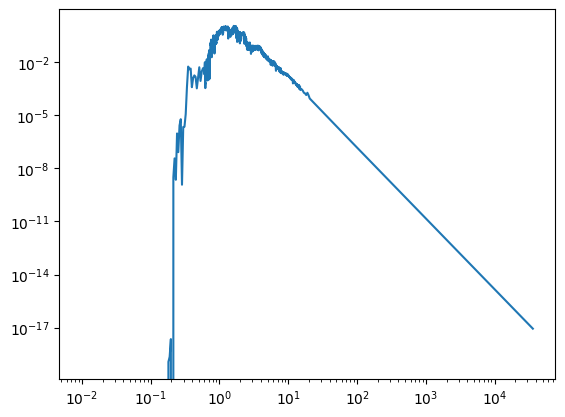

In [7]:
plt.plot(spec['lambda'], spec['flam_0.01'])
# plt.axvline(10)
plt.xscale('log')
plt.yscale('log')
# plt.ylim(1e-4, 1e-1)
# plt.xlim(5, 15)

In [10]:
with open(os.path.join('data', 'interpolate', 'rsg_s2.pkl'), 'rb') as f:
    models = pickle.load(f)

with open(os.path.join('data', 'interpolate', 'rsg_s2_test.pkl'), 'rb') as f:
    models_test = pickle.load(f)

In [11]:
tg, dtg, tug, lg = np.meshgrid(2800, 800, .01, 1e4, indexing='ij', sparse=True)
models['F070W']((tg, dtg, tug, lg)).flatten(), models_test['F070W']((tg, dtg, tug, lg)).flatten()

(array([27.93959705]), array([27.90953634]))

In [12]:
interp_val, interp_test = [], []
nrc_s = ['F070W', 'F090W', 'F115W', 'F150W', 'F200W', 'F250M', 'F277W', 'F356W', 'F444W']
wv_s = [float(i.split('F')[1].split('W')[0].split('M')[0]) for i in nrc_s]

wv_all = [float(i.replace('F', '').replace('W2', '').replace('M', '').replace('N', '').replace('W', ''))/100 
          for i in nrc_filts]
for f_ in nrc_filts:
    interp_val.append(models[f_]((tg, dtg, tug, lg)).flatten())
    interp_test.append(models_test[f_]((tg, dtg, tug, lg)).flatten())

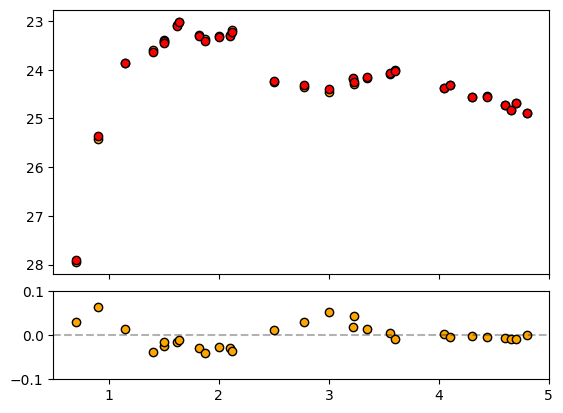

In [13]:
fig, (ax1, ax2) = plt.subplots(nrows=2, sharex=True, gridspec_kw={'height_ratios': [3, 1]})
ax1.scatter(wv_all, interp_val, fc='orange', ec='black')
ax1.scatter(wv_all, interp_test, fc='red', ec='black')
ax1.invert_yaxis()

ax2.scatter(wv_all, np.array(interp_val)-np.array(interp_test), fc='orange', ec='black')
ax2.axhline(0.0, ls='--', color='black', alpha=0.3)
ax2.set_ylim(-0.1, 0.1)

fig.subplots_adjust(hspace=0.1)

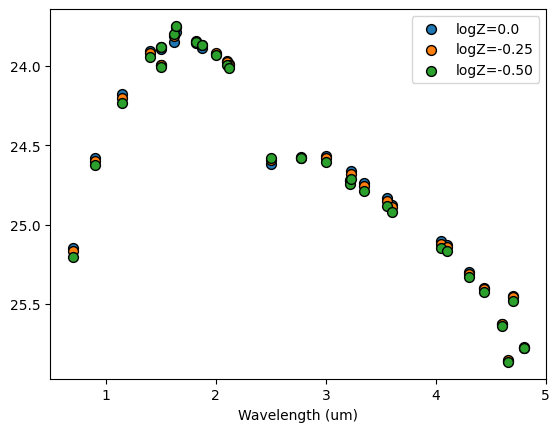

In [31]:
with open('/Users/aswin/rsg_phot/data/interpolate/rsg_sil_r2_z0.00_ext.pkl', 'rb') as f:
    z0 = pickle.load(f)

with open('/Users/aswin/rsg_phot/data/interpolate/rsg_sil_r2_z-0.25_ext.pkl', 'rb') as f:
    z25 = pickle.load(f)

with open('/Users/aswin/rsg_phot/data/interpolate/rsg_sil_r2_z-0.50_ext.pkl', 'rb') as f:
    z50 = pickle.load(f)

theta = (4000, 800, 0.01, 1e4, 3.1, 0.5)
params = np.meshgrid(*theta, indexing='ij', sparse=True)
mz0 = np.array([z0[f](params).flatten()[0] for f in nrc_filts])
mz25 = np.array([z25[f](params).flatten()[0] for f in nrc_filts])
mz50 = np.array([z50[f](params).flatten()[0]+10 for f in nrc_filts])

plt.scatter(wv_all, mz0, s=50, ec='black', label='logZ=0.0')
plt.scatter(wv_all, mz25, s=50, ec='black', label='logZ=-0.25')
plt.scatter(wv_all, mz50, s=50, ec='black', label='logZ=-0.50')
plt.legend()
plt.xlabel('Wavelength (um)')
plt.gca().invert_yaxis()

In [ ]:
dustgen = dust.dusty_gen(modeldir='/Users/aswin/rsg_phot/data/marcs/m1.00_g0.00/')
dustgen.gen_grid(grid_temps=[4000.0], grid_dust_temps=[800.0], redo_dusty=True, tb_overwrite=True)

### mcmc

In [5]:
sedfit = parallel_sed_fit(gal='ngc5643', 
                          procdir='data/dolphot/ngc5643',
                          photfile_path='data/dolphot/ngc5643', 
                          modeltype='MARCS',
                          dm=30.57, 
                          dmerr=0.06, 
                          z=-0.25, 
                          trgb=('F090W', 26.20), 
                          keep_narrow=False, 
                          ncores=1)
# rsgcat = sedfit.apply_initial_cuts()
# rsgcat.to_csv('data/dolphot/ngc5643/rsgcat_chimin.csv', index=False)

DOLPHOT catalog contains 1804516 objects after photometry cuts
rsg_sedfit [@ Mon, 27 Oct 2025 19:32:23] [l 120] - INFO - DOLPHOT catalog contains 1804516 objects after photometry cuts


In [4]:
df_sil = pd.read_csv('data/dolphot/ngc5643/ngc5643_sil_rsgcat.csv')
df_grf = pd.read_csv('data/dolphot/ngc5643/ngc5643_grf_rsgcat.csv')
df_sil.set_index('index', inplace=True)
df_grf.set_index('index', inplace=True)

grfm = np.array([i in df_sil.index for i in df_grf.index])
silm = np.array([i in df_grf.index for i in df_sil.index])

df1 = df_sil[~silm]
df2 = df_grf[~grfm]
df3 = df_sil[silm][df_sil[silm]['chimin'].values < df_grf[grfm]['chimin'].values]
df4 = df_grf[grfm][df_sil[silm]['chimin'].values > df_grf[grfm]['chimin'].values]
rsgcat = pd.concat([df1, df2, df3, df4])

In [5]:
# rsgcat = pd.read_csv('data/dolphot/ngc5643/rsgcat_chimin.csv')
sedfit = parallel_sed_fit(gal='ngc5643', 
                          procdir='data/dolphot/ngc5643', 
                          photfile_path='data/dolphot/ngc5643', 
                          dm=30.57, 
                          dmerr=0.06, 
                          z=-0.25, 
                          modeltype='MARCS',
                          trgb=('F090W', 26.20), 
                          keep_narrow=False, 
                          ncores=1,
                          rsgcat=rsgcat)

DOLPHOT catalog contains 1804516 objects after photometry cuts
rsg_sedfit [@ Tue, 28 Oct 2025 21:14:25] [l 128] - INFO - DOLPHOT catalog contains 1804516 objects after photometry cuts


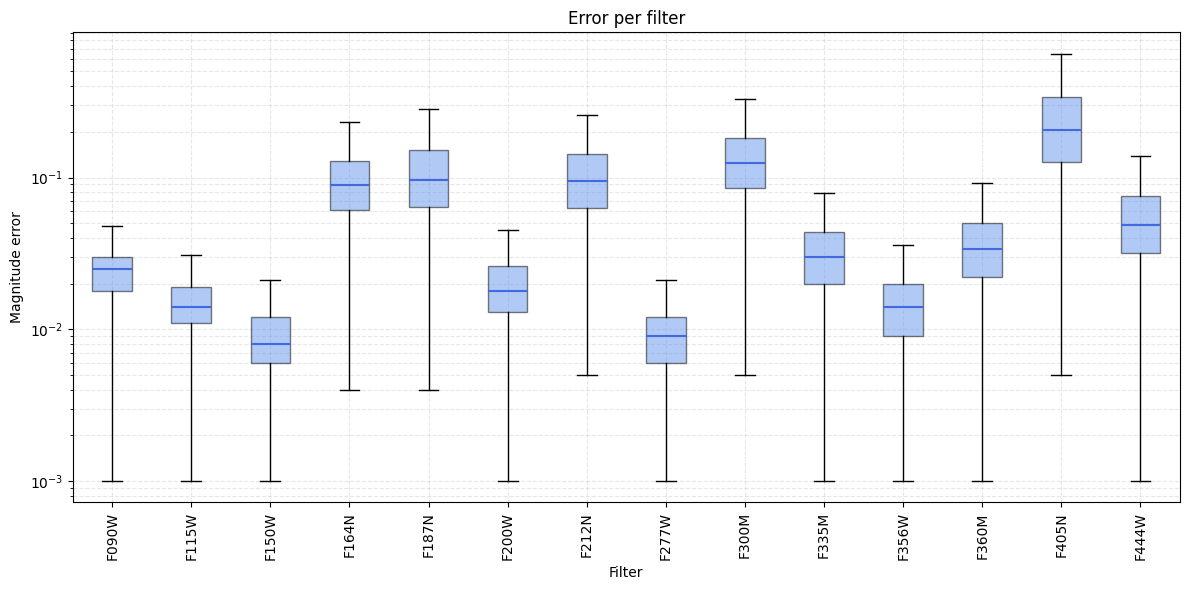

In [6]:
# boxplot of error distributions for all filters in rsgcat
errcols = sedfit.cols['errcols']
err_df = rsgcat[errcols].replace({9.999: np.nan, 99.999: np.nan})

data = [err_df[c].dropna().values for c in errcols]
labels = [c.replace('_err','') for c in errcols]

fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.boxplot(data, patch_artist=True, labels=labels, showfliers=False)

# styling
for box in bp['boxes']:
    box.set(facecolor='cornflowerblue', edgecolor='black', alpha=0.5)
for whisker in bp['whiskers']:
    whisker.set(color='black')
for median in bp['medians']:
    median.set(color='royalblue', linewidth=1.5)

ax.set_yscale('log')
ax.set_ylabel('Magnitude error')
ax.set_xlabel('Filter')
ax.set_title('Error per filter')
plt.xticks(rotation=90)
plt.grid(alpha=0.3, which='both', linestyle='--')
plt.tight_layout()
plt.show()

In [50]:
keep_narrow = False
testcol = rsgcat[rsgcat['tau_chisq'] > 1].sample(1).iloc[0]

phot = {'mag': testcol[sedfit.cols['magcols']].values,
        'magerr': testcol[sedfit.cols['errcols']].values,
        'inst_filt': np.array(sedfit.cols['flts']),
        'index': f'ngc5643_{int(testcol['index'])}'}

if not keep_narrow:
        fl_mask = np.array(['N' in i for i in phot['inst_filt']]) | np.array(['300M' in i for i in phot['inst_filt']])
        phot['mag'] = phot['mag'][~fl_mask]
        
        phot['magerr'] = phot['magerr'][~fl_mask]
        phot['inst_filt'] = phot['inst_filt'][~fl_mask]

limmask = (phot['mag'] > 90.0) | (phot['magerr'] > 90.0) | (np.isnan(phot['mag'])) | (np.isnan(phot['magerr']))
phot['mag'] = phot['mag'][~limmask]
phot['magerr'] = np.sqrt(phot['magerr'][~limmask]**2 + 0.01**2)
phot['inst_filt'] = phot['inst_filt'][~limmask]

In [56]:
mc_obj = mcmc(dm=30.57, dmerr=0.06, z=-0.5, comp='sil', model_type='MARCS')
mc_obj.verbose = True

fit_params, mcp, chipost, chibest = mc_obj.run_emcee(phot, nsteps=350, nwalkers=64, burn_in=75, calculate_chi = True)
fit_pe = np.array(list(fit_params.values()))
reader = mc_obj.load_backend(phot)
sample = np.array(reader.get_chain(flat=True, discard=75, thin=1))
probs = np.array(reader.get_log_prob(flat=True, discard=75, thin=1))
min_chi_params = sample[np.argmax(probs)]

Backend file: data/backends/ngc5643_21578_MARCS.h5
Backend name: 100199817521161092325986


100%|██████████| 350/350 [00:26<00:00, 12.99it/s]


Backend file: data/backends/ngc5643_21578_MARCS.h5
Backend name: 100199817521161092325986
Current number of samples in backend: 22400
Minimum chi^2 is: 7.4403873



temperature       :     3078.379 + 51.621000000000095 - 48.378999999999905
dust_temp         :     1558.345 + 171.65499999999997 -      288.345
tau_V             :         1.20 +         0.23 -         0.28
luminosity        :         4.07 +         0.14 -         0.13
Rv                :         3.89 +         1.41 -         1.28
Av                :        0.187 +        0.344 -        0.131
Backend file: data/backends/ngc5643_21578_MARCS.h5
Backend name: 100199817521161092325986


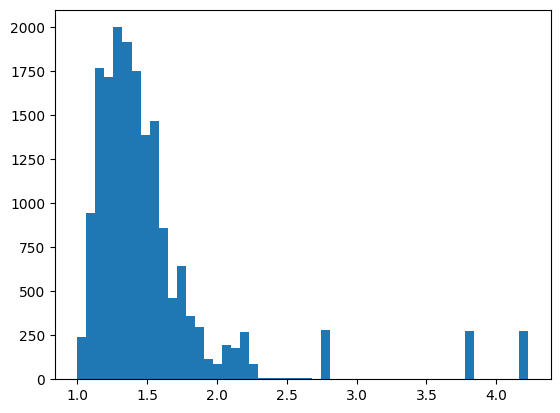

In [57]:
mask = np.isinf(np.abs(probs)) | np.isnan(probs)
_, prob_median, prob_sig = scs(probs)
mask = mask & (probs > prob_median - prob_sig)
params = sample[~mask,:]
prob = -1.0 * probs[~mask]
prob = prob / np.min(prob)

plt.figure()
plt.hist(prob, bins=50);

chi_limit = [1.00, 2.30, 3.50, 4.72, 5.89, 7.04]
mask = prob < 1.0 + 1 * chi_limit[5]
params_sample = params[mask,:]
prob_sample = prob[mask]

In [58]:
testcol[['teff_chisq', 'lum_chisq', 'tdust_chisq', 'tau_chisq', 'av_chisq', 'chimin']]

teff_chisq      3100.000000
lum_chisq      11030.693010
tdust_chisq     1400.000000
tau_chisq          1.204000
av_chisq           0.000000
chimin             0.004477
Name: 21578, dtype: float64

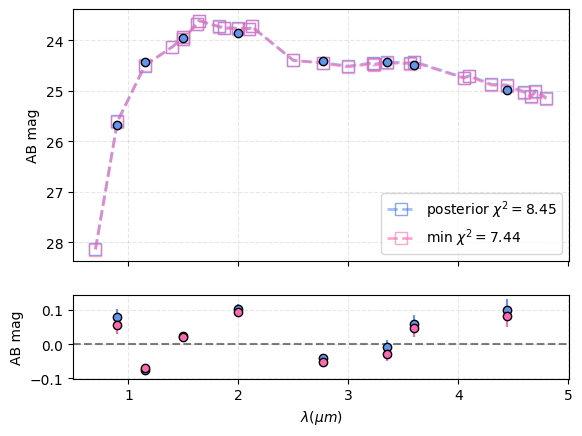

In [59]:
params = np.meshgrid(*fit_pe[:, 0], indexing='ij', sparse=True)
model_mag = np.array([mc_obj.model[f](params).flatten()[0] for f in phot['inst_filt']])+mc_obj.dm
chi1 = 0.5*np.sum((phot['mag'] - model_mag)**2 / phot['magerr']**2)/(len(model_mag)-1)
model_mag_plot = np.array([mc_obj.model[f](params).flatten()[0] for f in nrc_filts])+mc_obj.dm

mc_params = np.meshgrid(*min_chi_params, indexing='ij', sparse=True)
chi_mag = np.array([mc_obj.model[f](mc_params).flatten()[0] for f in phot['inst_filt']])+mc_obj.dm
chi2 = 0.5*np.sum((phot['mag'] - chi_mag)**2 / phot['magerr']**2)/(len(chi_mag)-1)
chi_mag_plot = np.array([mc_obj.model[f](mc_params).flatten()[0] for f in nrc_filts])+mc_obj.dm

fig, (ax1, ax2) = plt.subplots(nrows=2, sharex=True, gridspec_kw={'height_ratios': [3, 1]})
wv = np.array([float(i[1:4])/100 for i in phot['inst_filt']])
ax1.errorbar(x=wv, y=phot['mag'], yerr=phot['magerr'], linestyle='none', marker='o', markerfacecolor='cornflowerblue', 
             markeredgecolor='black', ecolor='cornflowerblue')
ax1.plot(wv_all, model_mag_plot, marker = 's', markerfacecolor = 'None', markeredgecolor = 'royalblue', 
         markersize = 8, ls='--', lw=2, alpha = 0.6, color='cornflowerblue', label = rf'posterior $\chi^2={chi1:.2f}$')
ax1.plot(wv_all, chi_mag_plot, marker = 's', markerfacecolor = 'None', markeredgecolor = 'hotpink', 
         markersize = 8, ls='--', lw=2, alpha = 0.6, color='hotpink', label = rf'min $\chi^2={chi2:.2f}$')
ax1.grid(alpha=0.3, linestyle='--')
ax1.invert_yaxis()
ax1.legend()
ax1.set_ylabel('AB mag')

ax2.errorbar(wv, phot['mag'] - model_mag, yerr=phot['magerr'], linestyle='none', marker='o', markerfacecolor='cornflowerblue',
             markeredgecolor='black', ecolor='cornflowerblue', label = 'posterior sample')
ax2.errorbar(wv, phot['mag'] - chi_mag, yerr=phot['magerr'], linestyle='none', marker='o', markerfacecolor='hotpink',
             markeredgecolor='black', ecolor='hotpink', label = r'min $\chi^2$')
ax2.grid(alpha=0.3, linestyle='--')
ax2.set_xlabel(r'$\lambda(\mu m)$')
ax2.set_ylabel('AB mag')
ax2.axhline(0.0, linestyle='--', alpha=0.5, color='black');
# plt.savefig(f'plots/rsg_mcmc_err{len(glob.glob('plots/rsg_mcmc_err*')) + 1}.png', bbox_inches='tight', dpi=500)
# plt.savefig('plots/rsg_mcmc14.png', bbox_inches='tight', dpi=500)

In [60]:
print('raw chi^2:', 0.5*np.sum((phot['mag'] - chi_mag)**2)/(len(chi_mag)-1))

raw chi^2: 0.0021346594691173336


In [61]:
mc_params

(array([[[[[[3053.01485303]]]]]]),
 array([[[[[[1765.42093992]]]]]]),
 array([[[[[[1.49055641]]]]]]),
 array([[[[[[4.0477722]]]]]]),
 array([[[[[[4.46828006]]]]]]),
 array([[[[[[0.02904115]]]]]]))

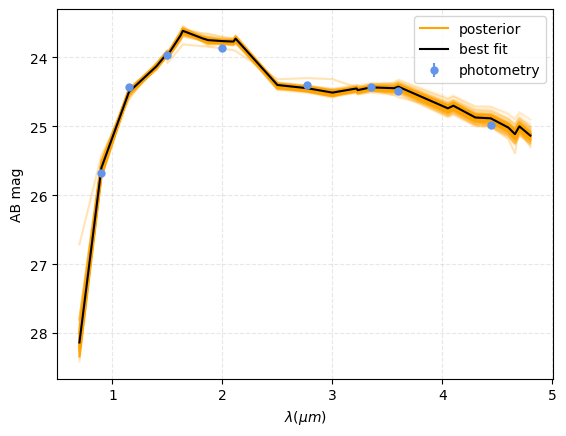

In [62]:
wv = np.array([float(i[1:4])/100 for i in phot['inst_filt']])
plt.errorbar(x=wv, y=phot['mag'], yerr=phot['magerr'], linestyle='none', marker='o', 
             markerfacecolor='cornflowerblue', markeredgecolor='none', ecolor='cornflowerblue', label='photometry')

wv_all = [float(i.replace('F', '').replace('W2', '').replace('M', '').replace('N', '').replace('W', ''))/100 
          for i in nrc_filts]

csm = sample#[5000:]
inds = np.random.randint(len(csm), size=200)

for i, idx in enumerate(inds):
    model_mag = np.array([mc_obj.model[f](csm[idx]).flatten()[0] for f in nrc_filts])+mc_obj.dm
    if i==0:
        plt.plot(wv_all, model_mag, alpha = 1.0, color='orange', label='posterior')
    else:
        plt.plot(wv_all, model_mag, alpha = 0.1, color='orange')

params = np.meshgrid(*fit_pe[:, 0], indexing='ij', sparse=True)

best_model_mag = np.array([mc_obj.model[f](params).flatten()[0] for f in nrc_filts])+mc_obj.dm
plt.plot(wv_all, best_model_mag, color='black', label='best fit')

plt.legend()
plt.xlabel(r'$\lambda(\mu m)$')
plt.ylabel('AB mag')
plt.grid(alpha=0.3, linestyle='--')
plt.gca().invert_yaxis()
# plt.savefig('plots/mc_default_move.png', bbox_inches='tight', dpi=500)

root [@ Tue, 28 Oct 2025 21:58:52] [l 718] - WARNING - Too few points to create valid contours
root [@ Tue, 28 Oct 2025 21:58:52] [l 718] - WARNING - Too few points to create valid contours
root [@ Tue, 28 Oct 2025 21:58:52] [l 718] - WARNING - Too few points to create valid contours


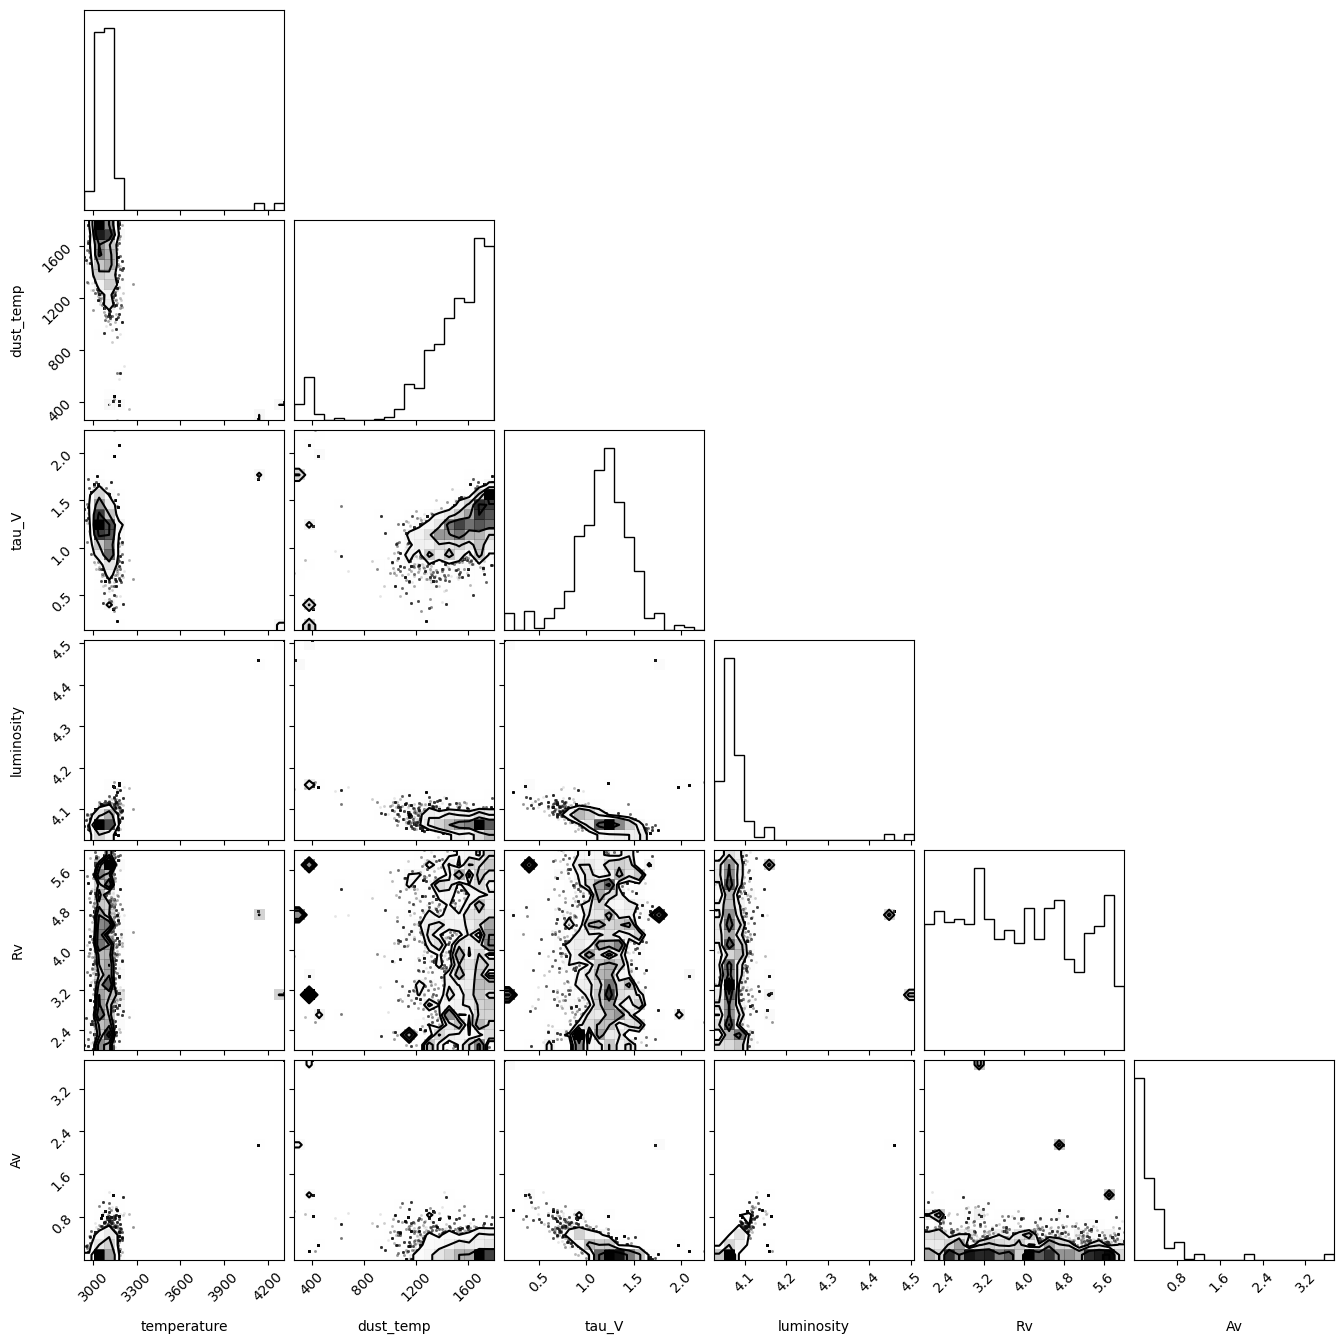

In [63]:
fig = corner.corner(
    sample, labels=mc_obj.model_fit_params,
    
);

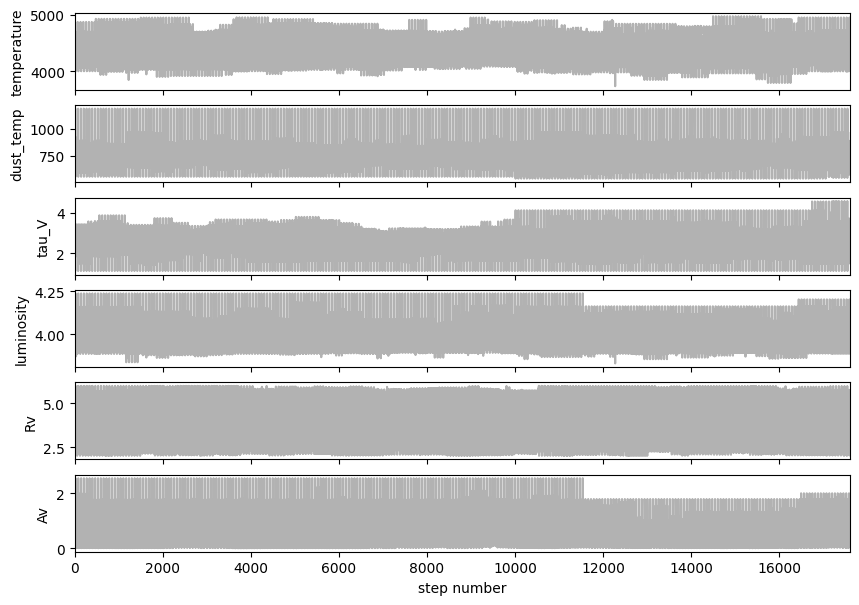

In [23]:
labels = mc_obj.model_fit_params
fig, axes = plt.subplots(len(labels), figsize=(10, 7), sharex=True)
for i in range(len(labels)):
    ax = axes[i]
    ax.plot(sample[:, i], "k", alpha=0.3)
    ax.set_xlim(0, len(sample))
    ax.set_ylabel(labels[i])
    # ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

### SBI

In [70]:
train = pd.read_csv('data/sbi/sim_MARCS_sil_Z-0.5.csv')
train['temperature'] = np.log10(train['temperature'])
train['dust_temp'] = np.log10(train['dust_temp'])
rsgcat = pd.read_csv('data/sbi/ngc4449_sil_rsgcat.csv')
mags = train[train.columns[6:]]
params = train[train.columns[:6]]

In [72]:
sedfit = parallel_sed_fit(gal='ngc4449', 
                          procdir='data/dolphot/ngc4449', 
                          photfile_path=None, 
                          dm=28.02, 
                          dmerr=0.32, 
                          z=-0.50, 
                          modeltype='MARCS',
                          trgb=('F090W', 25.11), 
                          keep_narrow=True, 
                          ncores=1,
                          rsgcat=rsgcat)

In [107]:
train_err = np.zeros((len(train), len(sedfit.cols['errcols'])))
for i, col in enumerate(sedfit.cols['errcols']):
    err = rsgcat[col].values
    mask = np.isnan(err) | (err > 0.5)
    err = err[~mask]
    kde = gaussian_kde(err)
    resamp_errs = kde.resample(len(train))
    resamp_errs[resamp_errs < 0.01] = 0.01
    train_err[:, i] = resamp_errs

In [108]:
x_train = np.array(params, dtype=float)
y_mags = mags[sedfit.cols['flts']]
y_err = pd.DataFrame(train_err, columns=sedfit.cols['errcols'])
y_train = pd.concat([y_mags, y_err], axis=1)
y_train = np.array(y_train, dtype=float)

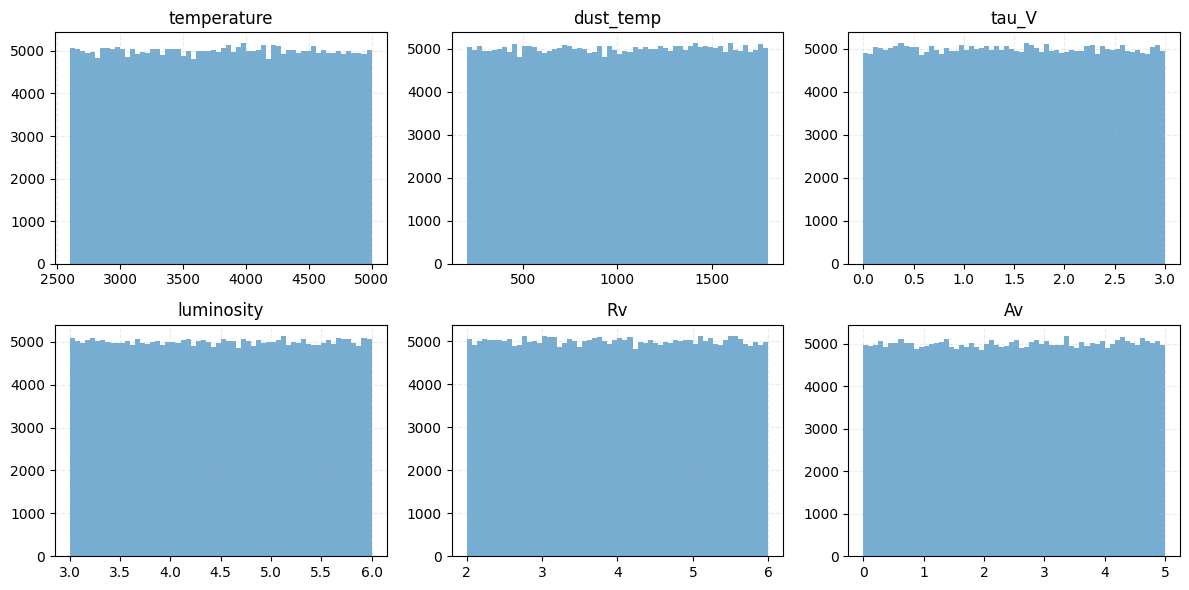

In [ ]:
# plot distributions for all parameters in X
cols = X.columns.tolist()
n = len(cols)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    data = X[col].dropna().values
    ax.hist(data, bins=60, density=False, alpha=0.6, color='C0')
    # overlay a KDE
    try:
        kde = gaussian_kde(data)
        xs = np.linspace(data.min(), data.max(), 300)
        ax.plot(xs, kde(xs), color='C1', lw=1.5)
    except Exception:
        pass
    ax.set_title(col)
    ax.grid(alpha=0.25, linestyle='--')

# hide any unused subplots
for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [109]:
device = 'cpu'
prior_low   = sbi_pp.prior_from_train('ll', x_train=x_train)
prior_high  = sbi_pp.prior_from_train('ul', x_train=x_train)
lower_bounds = torch.tensor(prior_low).to(device)
upper_bounds = torch.tensor(prior_high).to(device)
prior = sbi_utils.BoxUniform(low=lower_bounds, high=upper_bounds, device=device)

In [111]:
anpe = inference.NPE(prior=prior,
                      density_estimator=posterior_nn('nsf', hidden_features=50, num_transforms=5, num_bins=20, 
                                                     z_score_theta='independent', z_score_x='independent'),
                      device=device,)
x_tensor = torch.as_tensor(x_train.astype(np.float32)).to(device)
y_tensor = torch.as_tensor(y_train.astype(np.float32)).to(device)
anpe.append_simulations(x_tensor, y_tensor)
p_x_y_estimator = anpe.train(training_batch_size=256, use_combined_loss=True, validation_fraction=0.1, 
                             stop_after_epochs=50, show_train_summary=True)

 Neural network successfully converged after 437 epochs.
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 437
        Best validation performance: -18.5542
        -------------------------
        


tensorboard [@ Thu, 30 Oct 2025 00:36:02] [l 123] - INFO - No path found after /Users/aswin/rsg_phot/sbi-logs/NPE_C/2025-10-29T22_45_05.847964/events.out.tfevents.1761795905.Aswins-MacBook-Pro.local.6900.6
sbi.analysis.tensorboard_output [@ Thu, 30 Oct 2025 00:36:02] [l 80] - WARNING - For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=/Users/aswin/rsg_phot/sbi-logs/NPE_C/2025-10-29T22_45_05.847964' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

sbi.analysis.tensorboard_output [@ Thu, 30 Oct 2025 00:36:02] [l 89] - WARNING - Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


{'epochs_trained': [437], 'best_validation_loss': [-18.554229084243122], 'validation_loss': [-1.3047729114181974, -2.8796803075024204, -3.858514832635211, -4.4862745806702184, -5.296596779782548, -5.53465818747496, -5.682404179858346, -6.327250835223076, -7.171705641298213, -7.439731137365357, -7.755281354627039, -8.101390732659233, -8.098138454632881, -8.046114318391197, -8.187580858540331, -7.49690500080076, -8.05318935508402, -8.122605951423319, -8.990995235932179, -9.078480565649832, -9.413764399341028, -9.253261003738794, -9.338657036805765, -9.42654767810789, -9.64869685865875, -8.993074865422697, -9.176399393978281, -9.722426928006685, -8.580276326236563, -8.867822329203287, -10.415759918017265, -10.19183224083012, -10.588915148351946, -9.942343100523336, -10.33277039650159, -9.492157968700441, -10.410010566059341, -8.861457197075216, -10.94276858598758, -10.640947830982697, -10.759818435734154, -10.611649945250942, -10.783464635539259, -10.38989090715718, -10.418917664095886, -

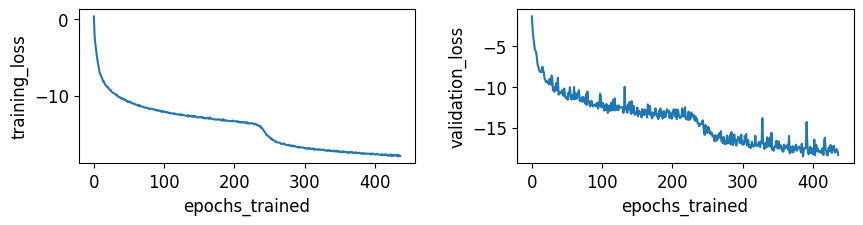

In [113]:
# save trained ANPE
torch.save(p_x_y_estimator.state_dict(), 'data/sbi/anpe_3.pt')

# save training summary
pickle.dump(anpe._summary, open('data/sbi/anpe_3.p', 'wb'))
print(anpe._summary)

from sbi.analysis import plot_summary

_ = plot_summary(
    anpe,
    tags=["training_loss", "validation_loss"],
    figsize=(10, 2),
)

In [126]:
p_x_y_estimator = anpe._build_neural_net(x_tensor, y_tensor)
p_x_y_estimator.load_state_dict(torch.load('data/sbi/anpe_3.pt', map_location=torch.device(device)))
anpe._x_shape = sbi_utils.x_shape_from_simulation(y_tensor)
hatp_x_y = anpe.build_posterior(p_x_y_estimator) 

obsmag = np.array(rsgcat[sedfit.cols['magcols']].loc[350]) - (sedfit.gen_mc_obj.dm+30)
obserr = np.array(rsgcat[sedfit.cols['errcols']].loc[350])
obserr = np.sqrt(obserr**2 + 0.01**2)
obs = np.concatenate([obsmag, obserr])
samp = hatp_x_y.sample((2500,), x=torch.as_tensor(obs.astype(np.float32)).to(device), show_progress_bars=True)

2700it [00:00, 75412.51it/s]            


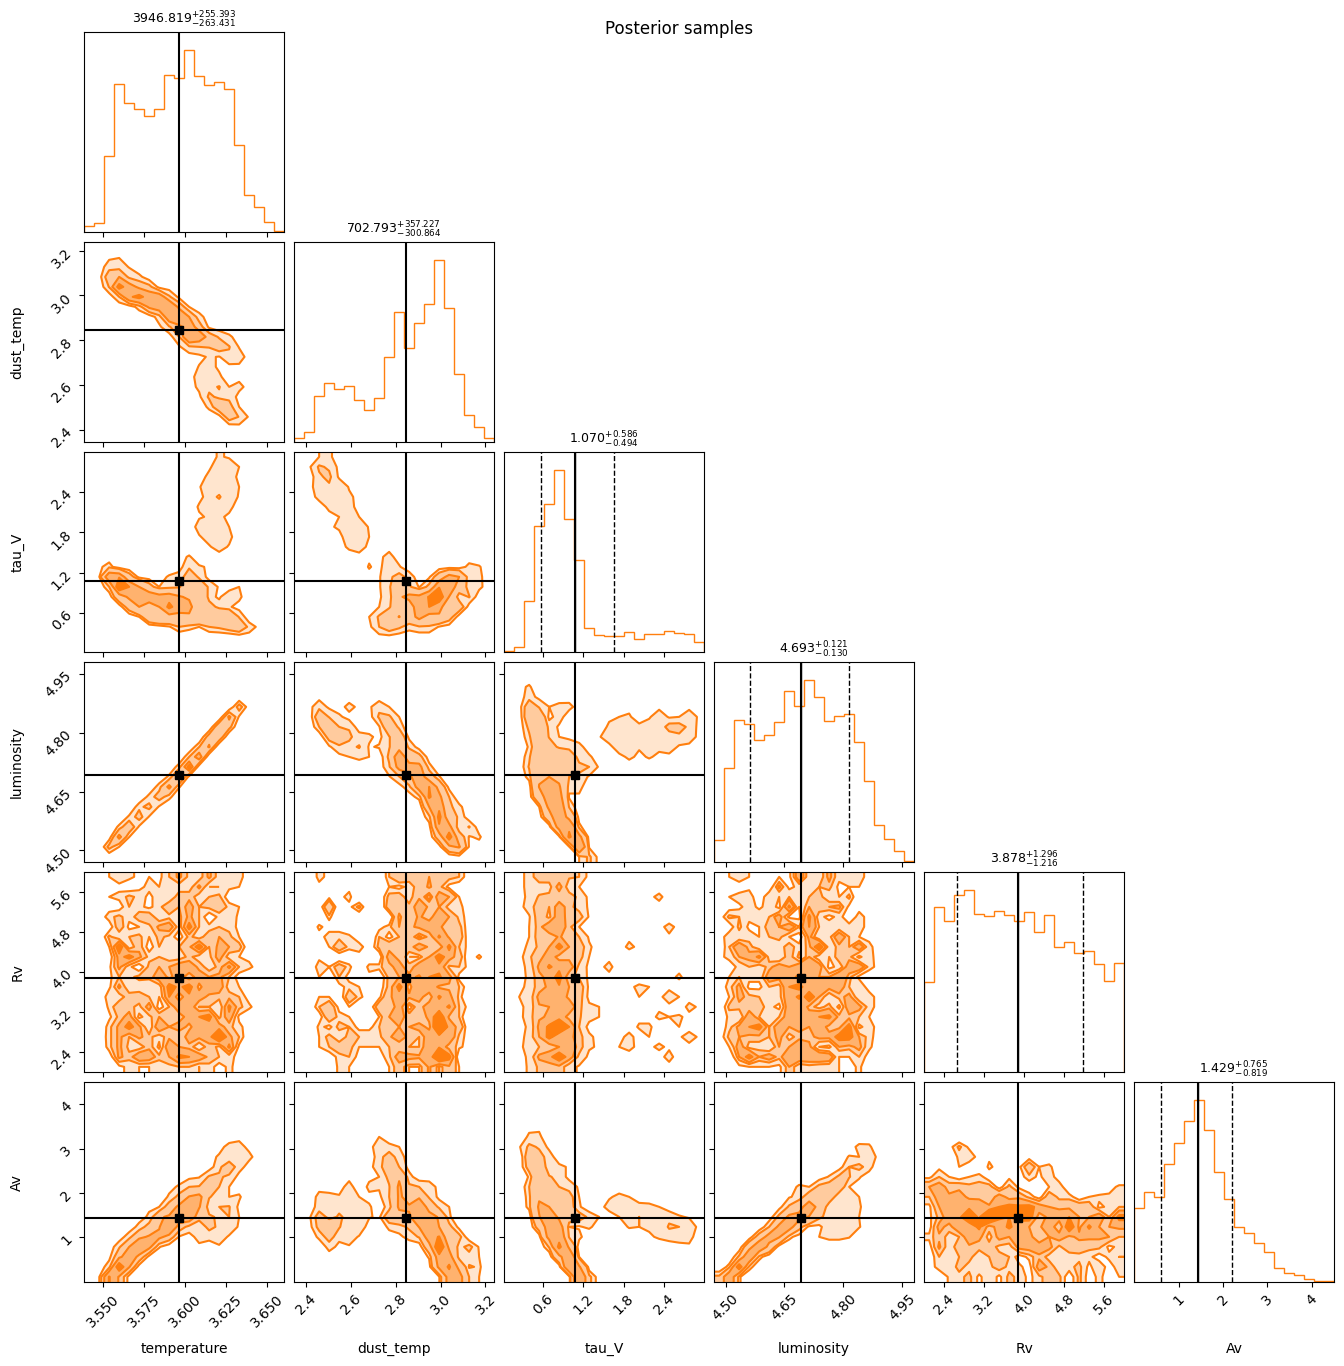

In [ ]:
# convert samples to numpy
samples = samp.cpu().numpy() if hasattr(samp, "cpu") else np.asarray(samp)
ndim = samples.shape[1]

# compute mean and 1-sigma
means = samples.mean(axis=0)
p16, p84 = np.percentile(samples, 16, axis=0), np.percentile(samples, 84, axis=0)

# make corner plot
fig = corner.corner(samples, labels=labels, color='C1', hist_kwargs={'density': True},
                    label_kwargs={'fontsize': 10}, show_titles=False, title_fmt='.3f', 
                    plot_datapoints=False, fill_contours=True, truth_color='k', truths=means)

# arrange axes and annotate means and 1-sigma
axes = np.array(fig.axes).reshape((ndim, ndim))
for i in range(ndim):
    if (i==0) | (i==1):
        means[i], p16[i], p84[i] = 10**means[i], 10**p16[i], 10**p84[i]
    # diagonal: add vertical lines and title with mean +/- sigma
    ax_diag = axes[i, i]
    ax_diag.axvline(means[i], color='k', lw=1)
    ax_diag.axvline(p16[i], color='k', lw=1, ls='--')
    ax_diag.axvline(p84[i], color='k', lw=1, ls='--')
    ax_diag.set_title(r"${0:.3f}^{{+{1:.3f}}}_{{-{2:.3f}}}$".format(means[i], p84[i]-means[i], means[i]-p16[i]), fontsize=9)
    # ax_diag.set_title(r"{means[i]:.3f} ^ {+{p84[i]:.3f}} - {p16[i]:.3f}".format(), fontsize=9)

    # off-diagonals: mark the mean point
    for j in range(i):
        ax = axes[i, j]
        ax.scatter(means[j], means[i], marker='x', color='k', s=30)

fig.suptitle("Posterior samples", fontsize=12)
plt.show()

Backend file: data/backends/ngc4449_350_MARCS.h5
Backend name: 59334252124320541904498


100%|██████████| 350/350 [00:37<00:00,  9.39it/s]


Backend file: data/backends/ngc4449_350_MARCS.h5
Backend name: 59334252124320541904498
Current number of samples in backend: 22400
Minimum chi^2 is: 4.2271737



temperature       :     3927.729 + 242.27100000000019 - 197.72899999999981
dust_temp         :     1154.351 + 195.6489999999999 - 204.3510000000001
tau_V             :        0.738 +        0.326 -        0.291
luminosity        :         4.65 +         0.78 -         0.74
Rv                :         3.93 +         1.41 -         1.32
Av                :         1.26 +         1.08 -         0.86
Backend file: data/backends/ngc4449_350_MARCS.h5
Backend name: 59334252124320541904498


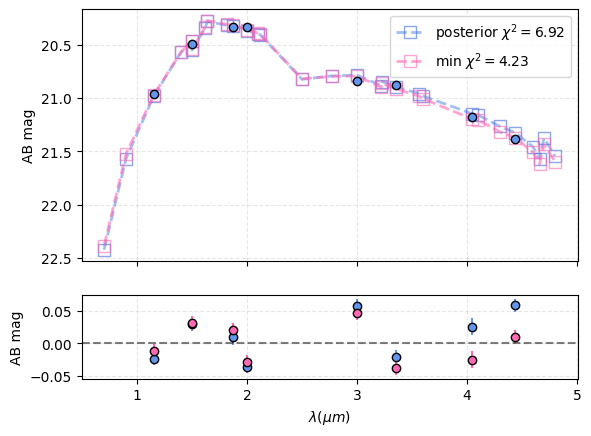

In [138]:
keep_narrow = True
testcol = rsgcat.loc[350]

phot = {'mag': np.array(testcol[sedfit.cols['magcols']], dtype=float),
        'magerr': np.array(testcol[sedfit.cols['errcols']], dtype=float),
        'inst_filt': np.array(sedfit.cols['flts']),
        'index': f'ngc4449_{int(testcol['index'])}'}

if not keep_narrow:
        fl_mask = np.array(['N' in i for i in phot['inst_filt']]) | np.array(['300M' in i for i in phot['inst_filt']])
        phot['mag'] = phot['mag'][~fl_mask]
        
        phot['magerr'] = phot['magerr'][~fl_mask]
        phot['inst_filt'] = phot['inst_filt'][~fl_mask]

limmask = (phot['mag'] > 90.0) | (phot['magerr'] > 90.0) | (np.isnan(phot['mag'])) | (np.isnan(phot['magerr']))
phot['mag'] = phot['mag'][~limmask]
phot['magerr'] = np.sqrt(phot['magerr'][~limmask]**2 + 0.01**2)
phot['inst_filt'] = phot['inst_filt'][~limmask]

mc_obj = mcmc(dm=28.02, dmerr=0.32, z=-0.5, comp='sil', model_type='MARCS')
mc_obj.verbose = True

fit_params, mcp, chipost, chibest = mc_obj.run_emcee(phot, nsteps=350, nwalkers=64, burn_in=75, calculate_chi = True)
fit_pe = np.array(list(fit_params.values()))
reader = mc_obj.load_backend(phot)
sample = np.array(reader.get_chain(flat=True, discard=75, thin=1))
probs = np.array(reader.get_log_prob(flat=True, discard=75, thin=1))
min_chi_params = sample[np.argmax(probs)]

params = np.meshgrid(*fit_pe[:, 0], indexing='ij', sparse=True)
model_mag = np.array([mc_obj.model[f](params).flatten()[0] for f in phot['inst_filt']])+mc_obj.dm
chi1 = 0.5*np.sum((phot['mag'] - model_mag)**2 / phot['magerr']**2)/(len(model_mag)-1)
model_mag_plot = np.array([mc_obj.model[f](params).flatten()[0] for f in nrc_filts])+mc_obj.dm

mc_params = np.meshgrid(*min_chi_params, indexing='ij', sparse=True)
chi_mag = np.array([mc_obj.model[f](mc_params).flatten()[0] for f in phot['inst_filt']])+mc_obj.dm
chi2 = 0.5*np.sum((phot['mag'] - chi_mag)**2 / phot['magerr']**2)/(len(chi_mag)-1)
chi_mag_plot = np.array([mc_obj.model[f](mc_params).flatten()[0] for f in nrc_filts])+mc_obj.dm

fig, (ax1, ax2) = plt.subplots(nrows=2, sharex=True, gridspec_kw={'height_ratios': [3, 1]})
wv = np.array([float(i[1:4])/100 for i in phot['inst_filt']])
ax1.errorbar(x=wv, y=phot['mag'], yerr=phot['magerr'], linestyle='none', marker='o', markerfacecolor='cornflowerblue', 
             markeredgecolor='black', ecolor='cornflowerblue')
ax1.plot(wv_all, model_mag_plot, marker = 's', markerfacecolor = 'None', markeredgecolor = 'royalblue', 
         markersize = 8, ls='--', lw=2, alpha = 0.6, color='cornflowerblue', label = rf'posterior $\chi^2={chi1:.2f}$')
ax1.plot(wv_all, chi_mag_plot, marker = 's', markerfacecolor = 'None', markeredgecolor = 'hotpink', 
         markersize = 8, ls='--', lw=2, alpha = 0.6, color='hotpink', label = rf'min $\chi^2={chi2:.2f}$')
ax1.grid(alpha=0.3, linestyle='--')
ax1.invert_yaxis()
ax1.legend()
ax1.set_ylabel('AB mag')

ax2.errorbar(wv, phot['mag'] - model_mag, yerr=phot['magerr'], linestyle='none', marker='o', markerfacecolor='cornflowerblue',
             markeredgecolor='black', ecolor='cornflowerblue', label = 'posterior sample')
ax2.errorbar(wv, phot['mag'] - chi_mag, yerr=phot['magerr'], linestyle='none', marker='o', markerfacecolor='hotpink',
             markeredgecolor='black', ecolor='hotpink', label = r'min $\chi^2$')
ax2.grid(alpha=0.3, linestyle='--')
ax2.set_xlabel(r'$\lambda(\mu m)$')
ax2.set_ylabel('AB mag')
ax2.axhline(0.0, linestyle='--', alpha=0.5, color='black');
# plt.savefig(f'plots/rsg_mcmc_err{len(glob.glob('plots/rsg_mcmc_err*')) + 1}.png', bbox_inches='tight', dpi=500)
# plt.savefig('plots/rsg_mcmc14.png', bbox_inches='tight', dpi=500)

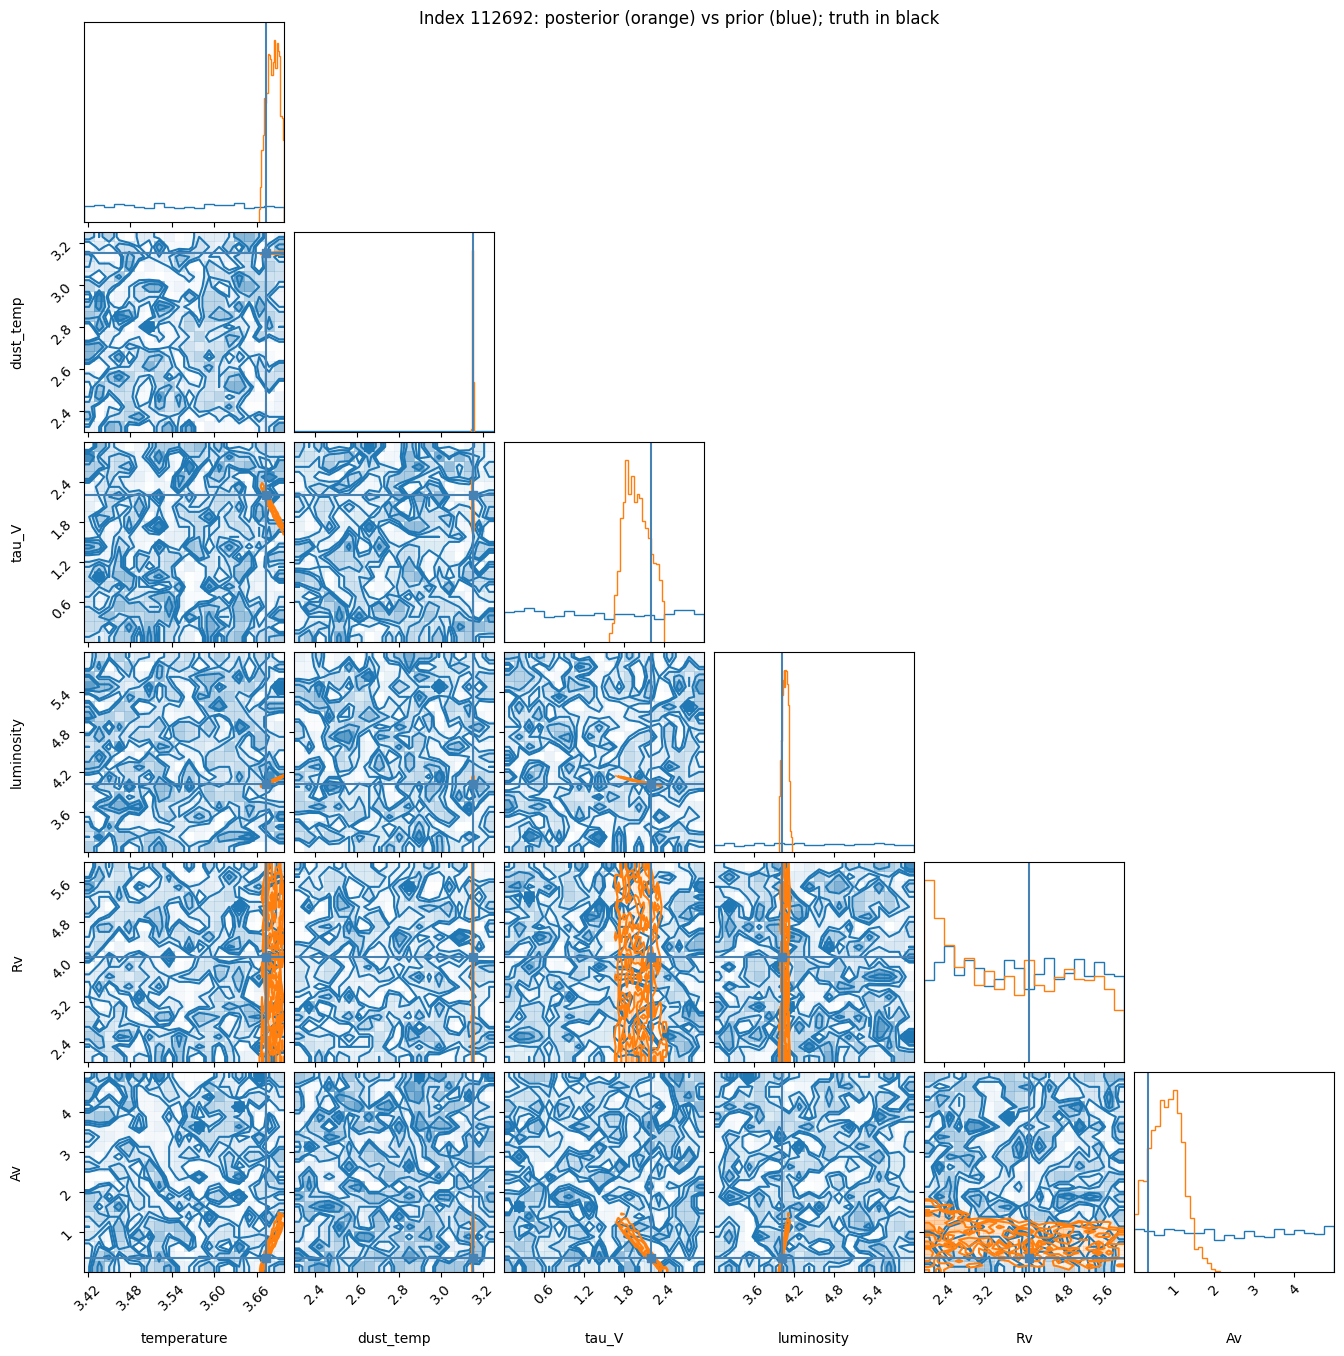

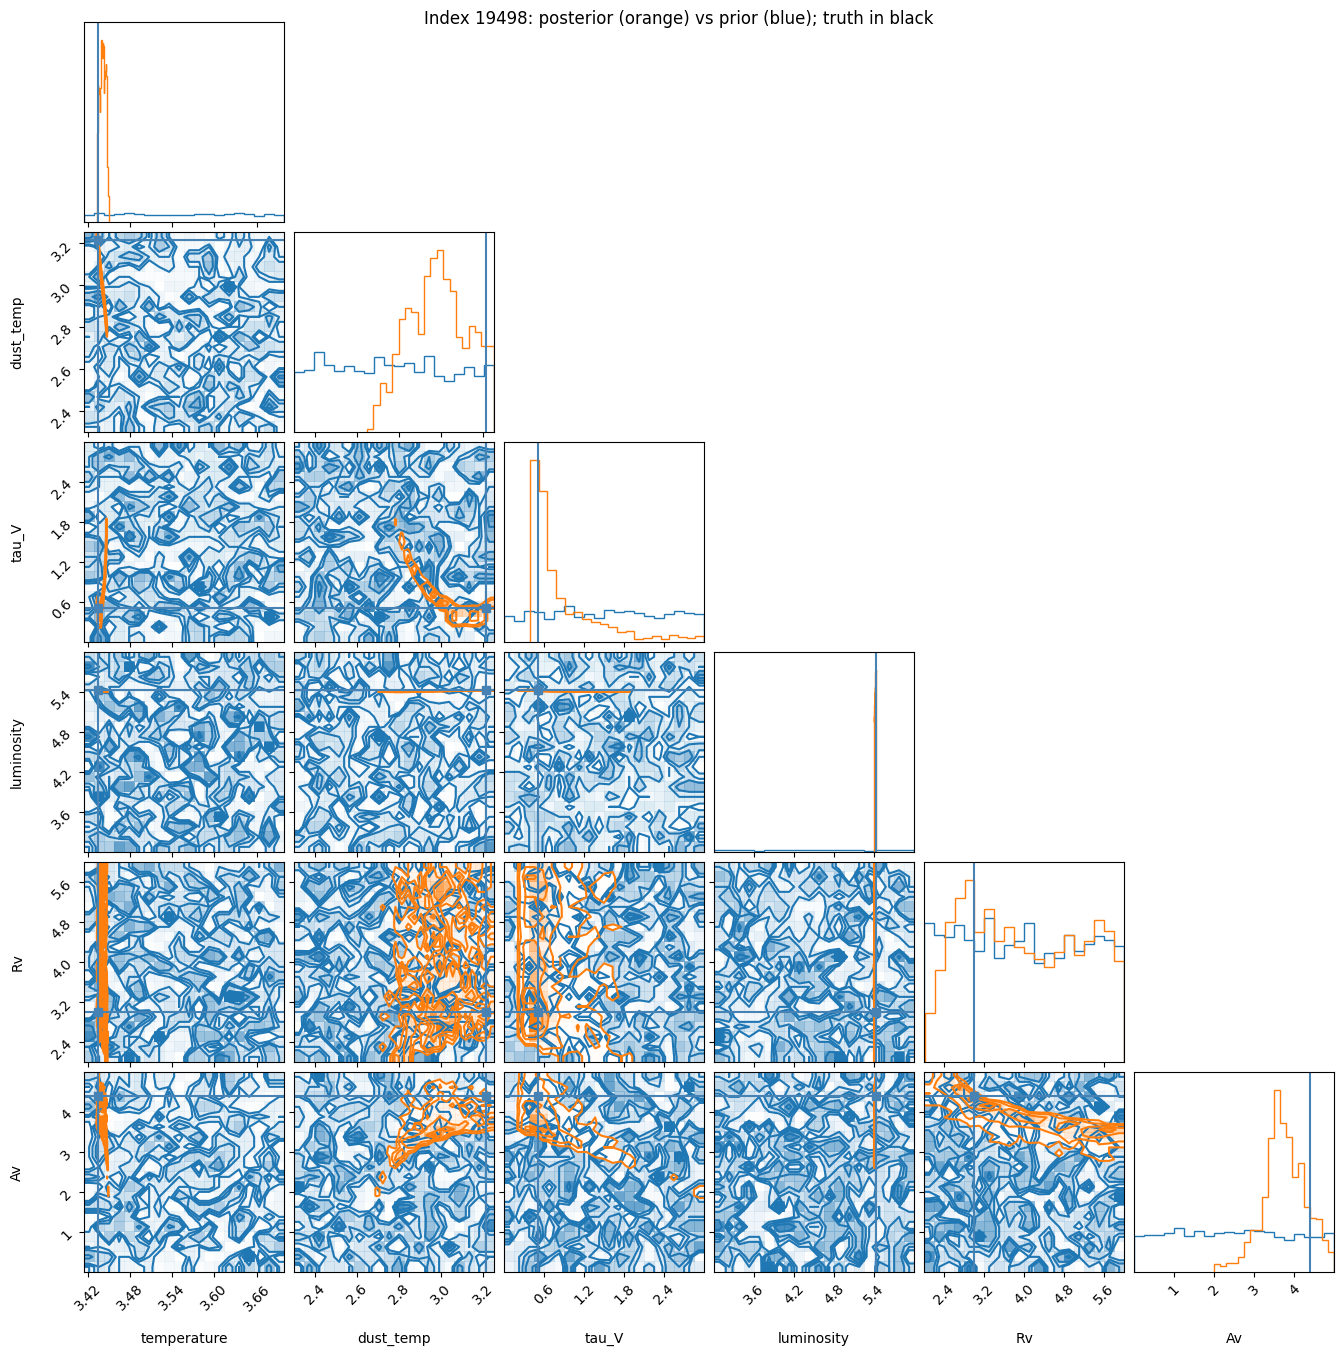

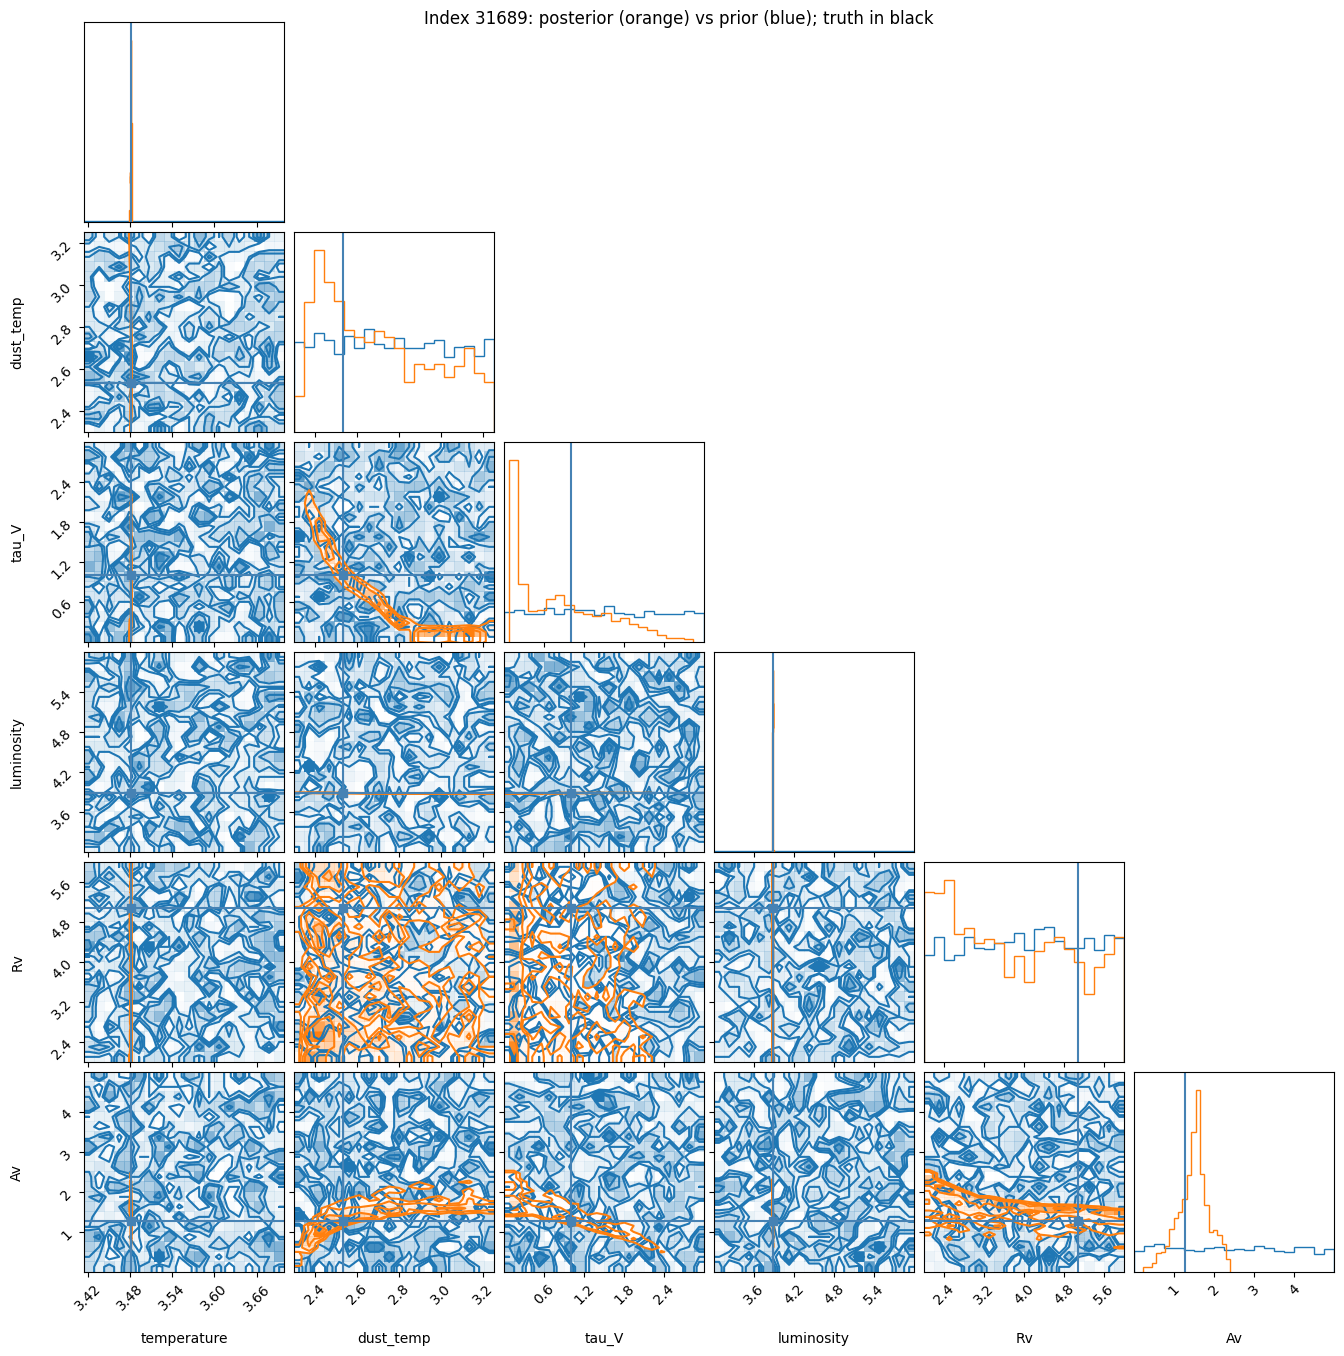

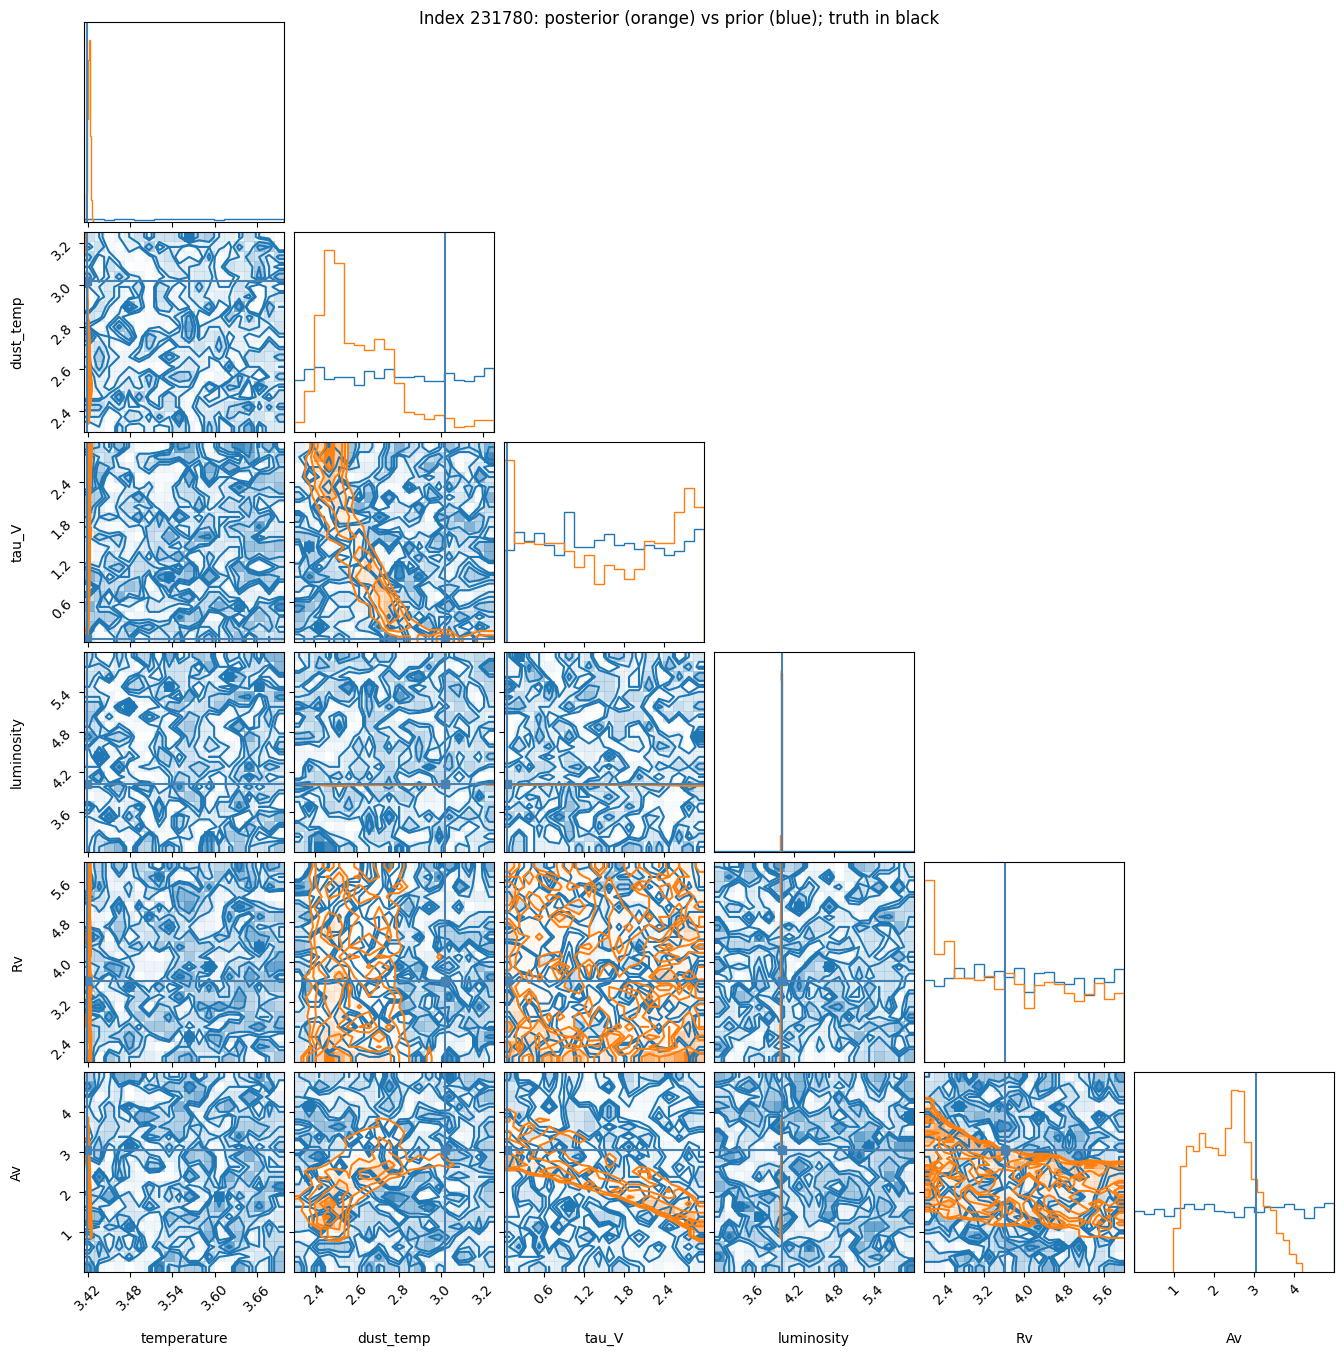

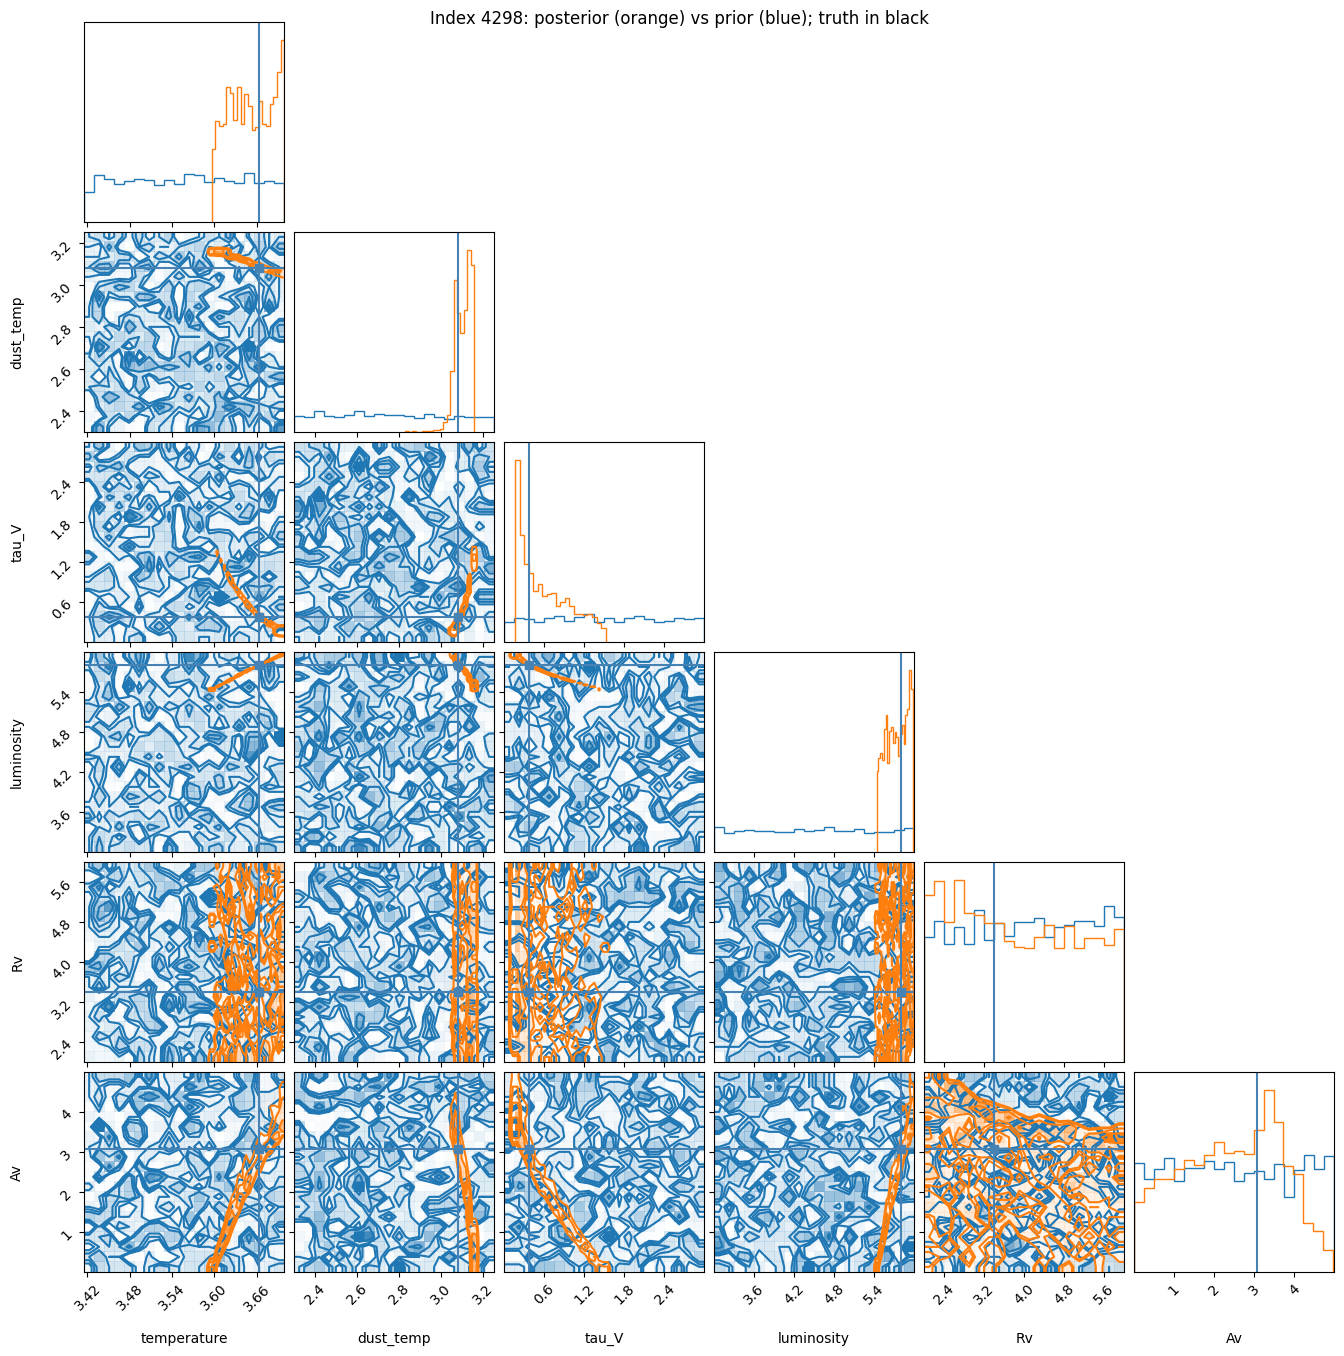

In [121]:
labels = list(params.columns) 

def plot_posterior_vs_prior(idx, nsamples_post=2000, nsamples_prior=2000, show=True):
    """
    Draw posterior samples conditioned on the training observation y_tensor[idx],
    draw prior samples, and show a corner plot overlaying prior (faint) and posterior (opaque).
    The true training parameters (x_train[idx]) are overplotted as black lines/points.
    """
    # observation (context) for posterior sampling
    y = y_tensor[idx].to(device) if isinstance(y_tensor, torch.Tensor) else torch.as_tensor(y_tensor[idx], device=device)
    # sample posterior conditional on this observation
    post_samples_t = hatp_x_y.sample((nsamples_post,), x=y, show_progress_bars=False)
    post_samples = post_samples_t.cpu().numpy()
    # sample prior for comparison
    prior_samples = prior.sample((nsamples_prior,)).cpu().numpy()

    truth = x_tensor[idx].cpu().numpy() if isinstance(x_tensor, torch.Tensor) else x_train[idx]

    # base plot: prior (faint)
    fig = corner.corner(prior_samples, labels=labels, color='C0', alpha=0.15,
                        truths=None, show_titles=False, plot_datapoints=False,
                        hist_kwargs={'density': True}, label_kwargs={'fontsize': 10})

    # overlay posterior (stronger)
    corner.corner(post_samples, labels=labels, color='C1', alpha=0.6, fig=fig,
                  truths=truth, truths_color='k', plot_datapoints=False,
                  hist_kwargs={'density': True}, label_kwargs={'fontsize': 10})

    fig.suptitle(f"Index {idx}: posterior (orange) vs prior (blue); truth in black", fontsize=12)
    if show:
        plt.show()
    return fig

# Example: plot for 3 random training indices
np.random.seed(0)
example_idxs = np.random.choice(len(x_train), size=5, replace=False)
for ix in example_idxs:
    _ = plot_posterior_vs_prior(int(ix), nsamples_post=2000, nsamples_prior=2000)

### base catalog

In [16]:
mc_obj = mcmc(dm=30.57, dmerr=0.06, z=-0.25)
mc_obj.verbose = True
mc_obj.bounds['luminosity'] = [10**3.5, 10**6.0]
mc_obj.bounds['temperature'] = [3500., 5000.]

sample_models = np.zeros((10000, len(nrc_filts)))
sample_params = mc_obj.get_init_pos(6, 10000)
sample_params = sample_params[sample_params[:, 0].argsort()]
for i, p_ in enumerate(sample_params):
    model_mag = np.array([mc_obj.model[f](sample_params[i]).flatten()[0] for f in nrc_filts]) + mc_obj.dm
    sample_models[i, :] = model_mag

In [17]:
mc_obj = mcmc(dm=30.57, dmerr=0.06, z=-0.25)
mc_obj.verbose = True
mc_obj.bounds['luminosity'] = [10**3.5, 10**3.6]

base_models = np.zeros((2000, len(nrc_filts)))
basedf_cols = [i+'_mag' for i in nrc_filts]

sample_params = mc_obj.get_init_pos(6, 1000)
for i, p_ in enumerate(sample_params):
    model_mag = np.array([mc_obj.model[f](sample_params[i]).flatten()[0] for f in nrc_filts]) + mc_obj.dm
    base_models[i, :] = model_mag


mc_obj.bounds['luminosity'] = [10**5.8, 10**6]
sample_params = mc_obj.get_init_pos(6, 1000)
for i, p_ in enumerate(sample_params):
    model_mag = np.array([mc_obj.model[f](sample_params[i]).flatten()[0] for f in nrc_filts]) + mc_obj.dm
    base_models[i+1000, :] = model_mag

min_model = np.max(base_models[base_models[:, 1] < 26.20], axis=0) #TRGB at F090W 26.20 mag for NGC5643
min_model_df = pd.DataFrame([dict(zip(basedf_cols, min_model))])

max_model = np.min(base_models[base_models[:, 1] < 26.20], axis=0)
max_model_df = pd.DataFrame([dict(zip(basedf_cols, max_model))])

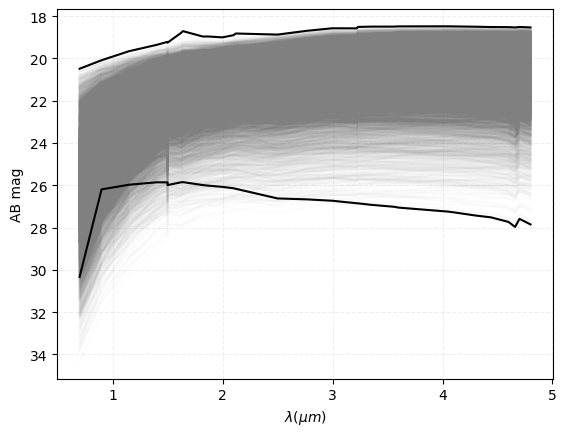

In [18]:
fig, ax = plt.subplots(1, 1)
for i, m_ in enumerate(sample_models):
    ax.plot(wv_all, m_, color='gray', alpha=0.02)
ax.plot(wv_all, min_model, color='black')
ax.plot(wv_all, max_model, color='black')
ax.invert_yaxis()
ax.grid(alpha=0.2, linestyle='--')
ax.set_xlabel(r'$\lambda(\mu m)$')
ax.set_ylabel('AB mag');

Text(0, 0.5, 'AB mag')

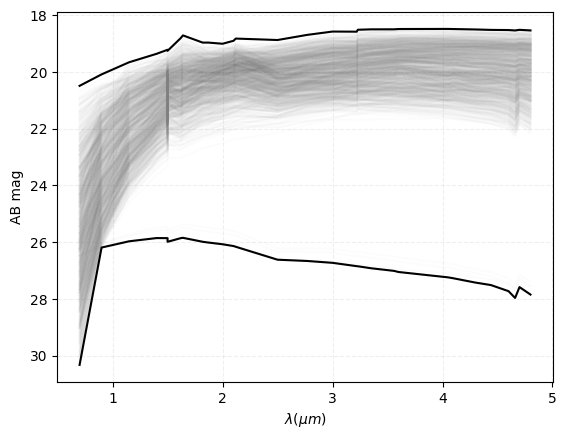

In [19]:
fig, ax = plt.subplots(1, 1)
for i, m_ in enumerate(base_models[base_models[:, 1] < 26.20]):
    ax.plot(wv_all, m_, color='gray', alpha=0.02)
ax.plot(wv_all, min_model, color='black')
ax.plot(wv_all, max_model, color='black')
ax.invert_yaxis()
ax.grid(alpha=0.2, linestyle='--')
ax.set_xlabel(r'$\lambda(\mu m)$')
ax.set_ylabel('AB mag')

In [48]:
def detmask(cat_mags_det, min_det=4):
    cat_wv = np.array([float(i[1:4])/100 for i in cat_mags_det.columns])

    opt_dets = cat_mags_det[cat_mags_det.columns[(cat_wv < 1.2)]]
    nir_dets = cat_mags_det[cat_mags_det.columns[(cat_wv > 1.2) & (cat_wv < 2.6)]]
    mir_dets = cat_mags_det[cat_mags_det.columns[(cat_wv > 2.6)]]

    ndetm = cat_mags_det.sum(axis=1) > min_det
    detm = (opt_dets.sum(axis=1) > 0) & (nir_dets.sum(axis=1) > 1) & (mir_dets.sum(axis=1) > 1) & ndetm

    return detm

def peakmask(cat_mags):
    cat_wv = np.array([float(i[1:4])/100 for i in cat_mags.columns])

    opt_dets = cat_mags[cat_mags.columns[(cat_wv < 1.2)]]
    nir_dets = cat_mags[cat_mags.columns[(cat_wv > 1.2) & (cat_wv < 2.6)]]
    mir_dets = cat_mags[cat_mags.columns[(cat_wv > 2.6)]]

    opt_peak, opt_med = opt_dets.min(axis=1), opt_dets.median(axis=1)
    nir_peak, nir_med = nir_dets.min(axis=1), nir_dets.median(axis=1)
    mir_peak, mir_med = mir_dets.min(axis=1), mir_dets.median(axis=1)

    req_nir_peak = (nir_peak < opt_peak) & (nir_peak < mir_peak)
    dust_peak = (nir_peak < opt_peak) & ((mir_med - opt_med) < -0.5) & ((nir_med - mir_med) < 1.0) & ((nir_med - mir_med) > 0)
    peakm = req_nir_peak | dust_peak
    print(req_nir_peak.sum(), dust_peak.sum())
    
    return peakm

def colormask(cat_mags, fls, sample_models, min_width=0.5, rel_err=0.25):
    cat_mags = cat_mags[fls]
    color_dict = {}
    cmb_iterator = list(itertools.combinations(nrc_filts, 2))
    idx_iterator = list(itertools.combinations(range(0, 29), 2))
    for i, j in zip(idx_iterator, cmb_iterator):
        f1, f2 = j[0], j[1]
        i1, i2 = i[0], i[1]
        index = f1+'_'+f2
        color_bounds = sample_models[:, i1] - sample_models[:, i2]
        cl_min = min(color_bounds) - rel_err #*np.abs(min(color_bounds))
        cl_max = max(color_bounds) + rel_err #*np.abs(max(color_bounds))
        cld = cl_max - cl_min
        if cld < min_width:
            cl_min = cl_min - (min_width - cld)/2
            cl_max = cl_max + (min_width - cld)/2
        color_dict[index] = (cl_min, cl_max)

    nwm = np.array(['N' in i for i in fls]) | np.array(['300M' in i for i in fls])
    mfls = fls[~nwm]

    colorm = np.array([True]*len(cat_mags))
    # colorm = np.zeros(len(cat_mags))
    for i, j in itertools.combinations(mfls, 2):
        idx_ = i.replace('_mag', '')+'_'+j.replace('_mag', '')
        cat_color = cat_mags[i] - cat_mags[j]
        dm = (cat_mags[i] > 90) | (cat_mags[j] > 90)
        colm_ = (cat_color > color_dict[idx_][0]) & (cat_color < color_dict[idx_][1])
        colm_ = colm_ | dm
        colorm = colorm & colm_
        # colorm = colorm + colm_.astype(int)
    # colorm = colorm > ((len(mfls)-1) * (len(mfls) - 2))/2 + 5
    return colorm, color_dict

fls = ['mag' in i for i in cat.columns]
fls = cat.columns[fls]
cat_mags = cat[fls]
cat_wv = np.array([float(i[1:4])/100 for i in cat_mags.columns])
cat_mags = cat_mags.replace(99.999, 0.5)
cat_mags = cat_mags.replace(np.nan, 0.5)

mindf = cat_mags-min_model_df[fls].to_numpy()
cat_mags = cat_mags.replace(0.5, 99.999)
maxdf = cat_mags-max_model_df[fls].to_numpy()
difm = (mindf < 0).all(axis=1) & (maxdf > 0).all(axis=1)
ndet = (cat_mags > 10) & (cat_mags < 38) 
ndetm = detmask(ndet)
base_mask = difm & ndetm  
rsgcat = cat[base_mask] #.replace(np.nan, 99.999)
print(len(rsgcat))

# f1, f2 = 'F115W', 'F200W'
# jkm = (rsgcat[f1+'_mag'] < 90) & (rsgcat[f2+'_mag'] < 90)
# cl, m = rsgcat[f1+'_mag'] - rsgcat[f2+'_mag'], rsgcat[f2+'_mag']
# # rsgmask = (m<26) & (m > lin(cl, -20.0, 33.0-3)) & (m < lin(cl, -8.0, 25+3.5))
# rsgmask = (m < 26) & (cl > 0.1) & jkm
# agbmask = (m < 26) & ((m > lin(cl, -10.0, 25+6)) | (m < lin(cl, -20.0, 33.0-5)))
# agbmask = agbmask & jkm
# rsgcat = rsgcat[rsgmask].replace(np.nan, 99.999)
# print(len(rsgcat))

# colorm, color_dict = colormask(rsgcat, fls, sample_models, min_width=0.2, rel_err=0.3)

# peakm = peakmask(rsgcat)
# rsgcat = rsgcat[colorm]
# print(len(rsgcat))
# rsgcat = rsgcat[~colorm][fls].replace(99.999, np.nan)

# f1, f2 = 'F115W', 'F200W'
# cl, m = rsgcat[f1+'_mag'] - rsgcat[f2+'_mag'], rsgcat[f2+'_mag']
# rsgmask = (m<26) & (m > lin(cl, -20.0, 33.0-3)) & (m < lin(cl, -8.0, 25+3.5))
# rsgcat = rsgcat[~rsgmask]

flts = [i.replace('_mag','') for i in fls]
magcols = [i+'_mag' for i in flts]
errcols = [i+'_err' for i in flts]

91730


In [260]:
min_width, rel_err = 1.0, 1.0

cat_mags = cat_mags[fls]
nwm = np.array(['N' in i for i in fls]) #| np.array(['M' in i for i in fls])
mfls = fls[~nwm]

colorm = np.array([True]*len(cat_mags))
for i, j in itertools.combinations(mfls, 2):
    idx_ = i.replace('_mag', '')+'_'+j.replace('_mag', '')
    cat_color = testcol[i] - testcol[j]
    dm = (testcol[i] > 90) | (testcol[j] > 90)
    colm_ = (cat_color > color_dict[idx_][0]) & (cat_color < color_dict[idx_][1])
    colm_ = colm_ | dm
    if not colm_:
        print(idx_, cat_color, color_dict[idx_], dm)
    colorm = colorm & colm_

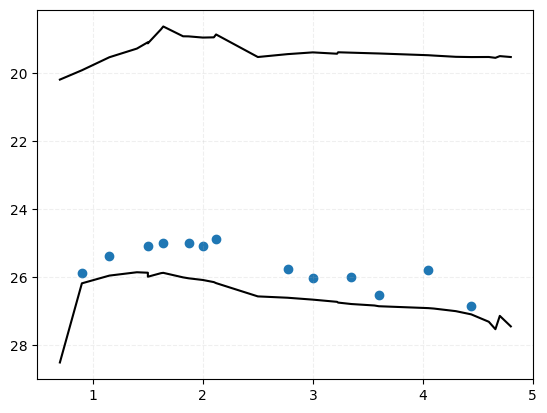

In [426]:
plt.scatter(cat_wv, rsgcat.sample(1).values[0])
plt.plot(wv_all, min_model, color='black')
plt.plot(wv_all, max_model, color='black')
plt.gca().invert_yaxis()
plt.grid(alpha=0.2, linestyle='--')

In [ ]:
teff_ = np.arange(2600, 5050, 50)
tdust_ = np.arange(200, 1800, 100)
tau_ = np.array(list(np.linspace(0.01, 2, 21)) + list(np.arange(2.5, 5.5, 0.5)))
Av_ = np.array(list(np.linspace(0, 1, 5))+ list(np.linspace(1.5, 3, 4)))
len(teff_) * len(tdust_) * len(tau_) * len(Av_)

In [ ]:
modeldf = pd.DataFrame(columns = ['Teff', 'Tdust', 'Tau', 'Av']+nrc_filts)
for a1 in tqdm(teff_):
    for a2 in tdust_:
        for a3 in tau_:
            for a4 in Av_:
                pm_ = [a1, a2, a3, 1e3, 3.1, a4]
                model_mag = np.array([mc_obj.model[f](pm_).flatten()[0] for f in nrc_filts]) + mc_obj.dm
                modeldf.loc[len(modeldf), ['Teff', 'Tdust', 'Tau', 'Av']+nrc_filts] = [a1, a2, a3, a4] + list(model_mag)
modeldf.to_csv('modeldf_ngc5643.csv', index=False)

In [ ]:
modeldf = pd.read_csv('data/dolphot/ngc5643/ngc5643_modeldf.csv')

In [ ]:
def chimin(phot, modeldf):
    modelmagval = modeldf[phot['inst_filt']].values
    submagval = modelmagval - phot['mag']
    meanval = np.average(submagval, weights = 1/phot['magerr']**2, axis=1)
    submagval = submagval - meanval[:, None]
    chisqe = np.sum(submagval**2/phot['magerr']**2, axis=1)/len(phot['mag'] - 1)
    chisq = np.sum(submagval**2, axis=1)/len(phot['mag'] - 1)
    minchisq = np.argmin(chisqe)

    # print(chisq[minchisq])
    # # otherbestmodel = modeldf.loc[55544][phot['inst_filt']].values - np.log10(21729/1e3)*2.5
    # otherbestmodel = chi_mag
    # photmag=phot['mag']
    # print(np.sum((otherbestmodel - photmag)**2)/(len(photmag) - 1))
    # print((otherbestmodel - photmag)**2)
    # print(submagval[minchisq]**2)

    bestparams = modeldf.loc[minchisq, ['Teff', 'Tdust', 'Tau', 'Av']].values
    pm_ = [bestparams[0], bestparams[1], bestparams[2], 1e3, 3.1, bestparams[3]]
    bestmodel = np.array([mc_obj.model[f](pm_).flatten()[0] for f in phot['inst_filt']]) + mc_obj.dm
    lum = 10**(np.mean((phot['mag'] - bestmodel)/-2.5)) * 1e3
    return chisq[minchisq], minchisq, lum, submagval[minchisq]

In [ ]:
c_, m_, l_, res = chimin(phot, modeldf)
print(c_, l_)
print(modeldf.loc[m_, ['Teff', 'Tdust', 'Tau', 'Av']])

In [ ]:
plt.plot(wv_all, modeldf.loc[m_][nrc_filts].values - np.log10(l_/1e3)*2.5, color='coral', ls='--', marker='s', markerfacecolor='none', markersize=8)
plt.plot(wv_all, chi_mag_plot, color='green', ls='--', marker='s', markerfacecolor='none', markersize=8)
# plt.plot(wv_all, modeldf.loc[17065][nrc_filts].values - np.log10(7479/1e3)*2.5, color='green', ls='--', marker='s', markerfacecolor='none', markersize=8)
plt.scatter(wv, phot['mag'], fc='cornflowerblue', ec='black')
# plt.scatter(wv_all, np.array([mc_obj.model[f]([3800, 1300, 0.1095, 56329, 3.1, 0.75]).flatten()[0] for f in nrc_filts]) + mc_obj.dm, color='blue')
plt.gca().invert_yaxis()

In [ ]:
rescat = pd.DataFrame(columns=sedfit.cols['flts'])

In [ ]:
keep_narrow = True
rsgcat[['chimin', 'teff', 'tdust', 'tau', 'av', 'lum']] = np.nan
for idx in tqdm(rsgcat.index):
    testcol = rsgcat.loc[idx]

    phot = {'mag': testcol[sedfit.cols['magcols']].values,
            'magerr': testcol[sedfit.cols['errcols']].values,
            'inst_filt': np.array(sedfit.cols['flts']),
            'index': f'ngc5643_{int(testcol['index'])}'}

    if not keep_narrow:
            fl_mask = np.array(['N' in i for i in phot['inst_filt']]) | np.array(['300M' in i for i in phot['inst_filt']])
            phot['mag'] = phot['mag'][~fl_mask]
            
            phot['magerr'] = phot['magerr'][~fl_mask]
            phot['inst_filt'] = phot['inst_filt'][~fl_mask]

    limmask = (phot['mag'] > 90.0) | (phot['magerr'] > 90.0) | (np.isnan(phot['mag'])) | (np.isnan(phot['magerr']))
    phot['mag'] = phot['mag'][~limmask]
    phot['magerr'] = phot['magerr'][~limmask]
    phot['inst_filt'] = phot['inst_filt'][~limmask]
    c_, m_, l_, res = chimin(phot, modeldf)
    rescat.loc[len(rescat), phot['inst_filt']] = res
#     rsgcat.loc[idx, ['chimin', 'lum']] = c_, l_
#     rsgcat.loc[idx, ['teff', 'tdust', 'tau', 'av']] = modeldf.loc[m_, ['Teff', 'Tdust', 'Tau', 'Av']].values

In [ ]:
fig, ax = plt.subplots()
resvals = []
for col in rescat.columns:
    nanmask = rescat[col].isna()
    resvals.append(rescat[col][~nanmask].values)
    print(col, np.std(rescat[col][~nanmask].values, ddof=1))
labels = sedfit.cols['flts']

bplot = ax.boxplot(resvals,
                   patch_artist=True,  # fill with color
                   tick_labels=labels)
ax.set_xticklabels(labels=labels, rotation = 90);

In [ ]:
rescat.to_csv('data/dolphot/ngc5643/rescat.csv', index=False)

### RSG-AGB split

In [ ]:
sedfit.cat = sedfit.read_cat(sedfit.photfile_path)
cat = sedfit.read_cat(sedfit.photfile_path)

DOLPHOT catalog contains 1804516 objects after photometry cuts
rsg_sedfit [@ Mon, 22 Sep 2025 14:47:05] [l 117] - INFO - DOLPHOT catalog contains 1804516 objects after photometry cuts


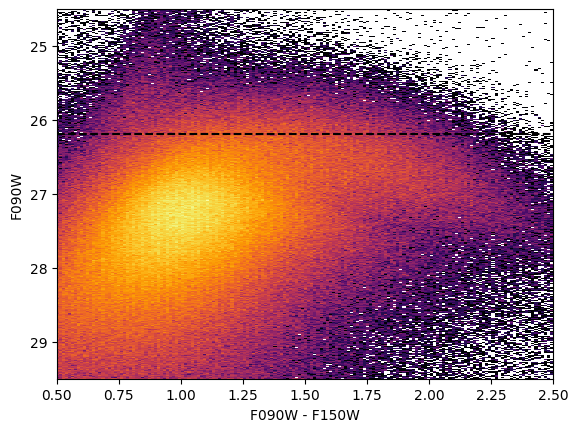

In [37]:
f1, f2 = 'F090W', 'F150W'
det_jk = (sedfit.cat[f'{f1}_mag'] > 15) & (sedfit.cat[f'{f1}_mag'] < 35) & (sedfit.cat[f'{f2}_mag'] > 15) & (sedfit.cat[f'{f2}_mag'] < 35)
plt.hist2d(sedfit.cat[det_jk][f'{f1}_mag'] - sedfit.cat[det_jk][f'{f2}_mag'], sedfit.cat[det_jk][f'{f1}_mag'], bins=1400, cmap = 'inferno', norm='log');
# plt.scatter(sedfit.cat[det_jk][f'{f1}_mag'] - sedfit.cat[det_jk][f'{f2}_mag'] + 26.28 - 28.02 - 25.90 + 28.02, sedfit.cat[det_jk][f'{f1}_mag'] + 26.28 - 28.02, s=0.001, color='orange', alpha=0.1);
# plt.scatter(sedfit.cat[det_jk][f'{f1}_mag'] - sedfit.cat[det_jk][f'{f2}_mag'], sedfit.cat[det_jk][f'{f1}_mag'], s=0.001, color='orange', alpha=0.1);
plt.axhline(26.19, ls='--', color='black')
plt.xlabel(f'{f1} - {f2}')
plt.ylabel(f'{f1}')
plt.xlim(0.5, 2.5)
plt.ylim(24.5, 29.5)
plt.gca().invert_yaxis()

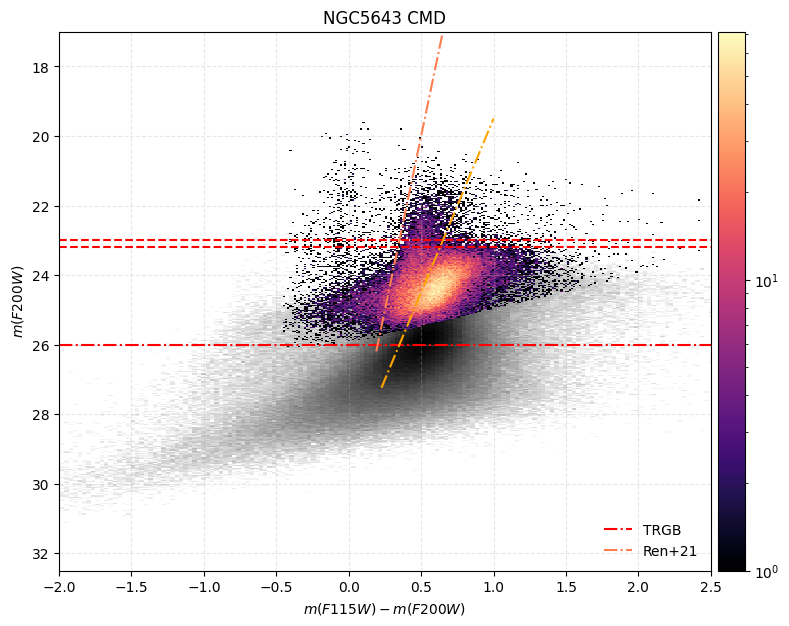

In [9]:
def lin(x, m, c): return m*x+c

fig, ax = plt.subplots(1, 1, figsize = (10, 7))
f1, f2 = 'F115W', 'F200W'

det_jk = (cat[f1+'_mag'] > 18) & (cat[f1+'_mag'] < 32) & (cat[f2+'_mag'] > 18) & (cat[f2+'_mag'] < 32)
cl, m = cat[det_jk][f1+'_mag'] - cat[det_jk][f2+'_mag'], cat[det_jk][f2+'_mag']
rsg_det_jk = (rsgcat[f1+'_mag'] > 18) & (rsgcat[f1+'_mag'] < 32) & (rsgcat[f2+'_mag'] > 18) & (rsgcat[f2+'_mag'] < 32)
rsg_cl, rsg_m = rsgcat[rsg_det_jk][f1+'_mag'] - rsgcat[rsg_det_jk][f2+'_mag'], rsgcat[rsg_det_jk][f2+'_mag']

ax.hist2d(cl, m, bins = 400, norm = 'log', cmap = 'Grays')
hist = ax.hist2d(rsg_cl, rsg_m, bins = 200, norm = 'log', cmap = 'magma')

ax.axhline(26, color = 'red', label='TRGB', linestyle = '-.')
ax.plot(np.linspace(0.1905, 1, 100), lin(np.linspace(0.1905, 1, 100), -20.0, 33.0-3), linestyle='-.', color = 'coral', label = 'Ren+21')
ax.plot(np.linspace(0.22625, 1, 100), lin(np.linspace(0.22625, 1, 100), -10.0, 25+4.5), linestyle='-.', color = 'orange')
# ax.scatter(phot['mag'][1] - phot['mag'][3], phot['mag'][3], marker='*', s=150, fc='orange', ec='black')

ax.axhline(23, color = 'red', linestyle = '--')
ax.axhline(23.2, color = 'red', linestyle = '--')

cbar = fig.colorbar(hist[3], ax = ax, pad = 0.009)
ax.set_xlabel(rf'$m({f1}) - m({f2})$')
ax.set_ylabel(rf'$m({f2})$')
ax.set_title('NGC5643 CMD')

ax.legend(loc = 'lower right', framealpha = 0)
ax.tick_params(axis='both', which='major')
ax.tick_params(axis='both', which='minor')
cbar.ax.tick_params() 
ax.grid(alpha = 0.3, linestyle = '--')
ax.set_xlim(-2, 2.5)
ax.set_ylim(32.5, 17)
plt.show()

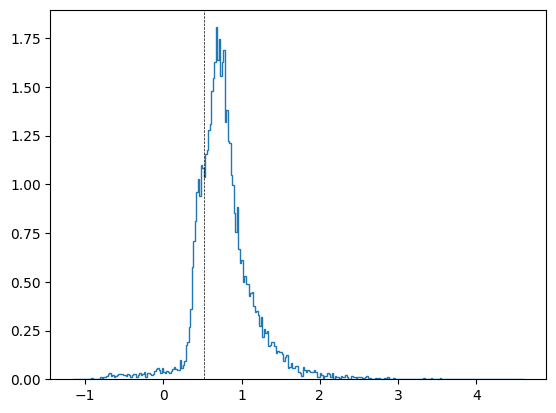

In [9]:
binm = (m > 23.2) & (m < 23.9) & (cl < 5)
cl_binm = cl[binm]
plt.hist(cl_binm, bins=300, histtype='step', density=True);
plt.axvline(0.52, ls='--', lw=0.5, color='black')
# plt.yscale('log')

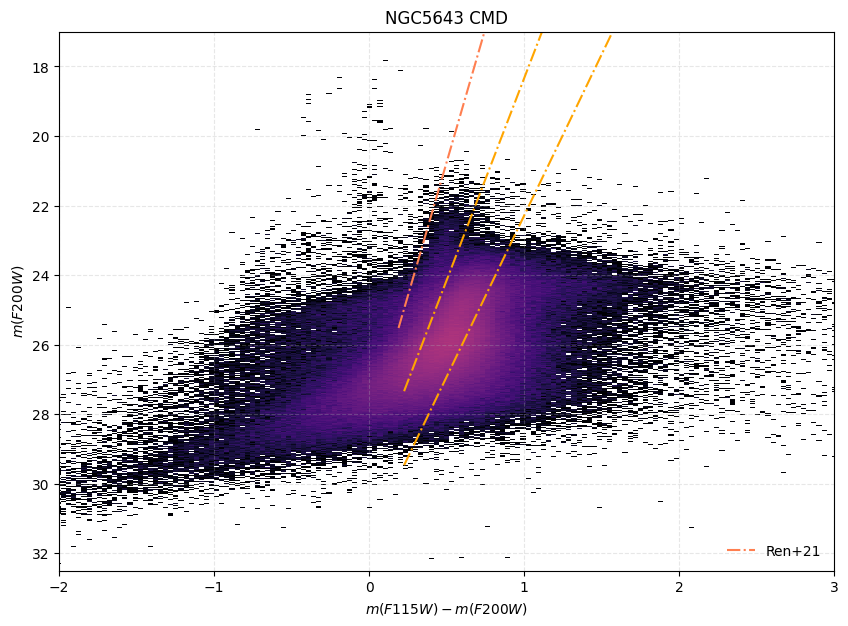

In [10]:
def lin(x, m, c): return m*x+c

fig, ax = plt.subplots(1, 1, figsize = (10, 7))
f1, f2 = 'F115W', 'F200W'

cl, m = cat[f1+'_mag'] - cat[f2+'_mag'], cat[f2+'_mag']
# rsg_cl, rsg_m = rsgcat[f1+'_mag'] - rsgcat[f2+'_mag'], rsgcat[f2+'_mag']
# mask = (cl > 0.5) & (cl < 1.2) & (m < 26)
# cl, m = cl[mask], m[mask]

hist = ax.hist2d(cl, m, bins = 5000, norm = 'log', cmap = 'magma')
# hist = ax.hist2d(rsg_cl, rsg_m, bins = 4000, norm = 'log', cmap = 'magma')
# plt.scatter(cl, m, s=0.1, alpha=0.9)

# ax.axhline(26, color = 'red', label='TRGB', linestyle = '-.')
ax.plot(np.linspace(0.1905, 1.5, 100), lin(np.linspace(0.1905, 1.5, 100) + 0.44, -15.366, 22.048-17.41+30.57), linestyle='-.', color = 'coral', label = 'Ren+21')
ax.plot(np.linspace(0.22625, 2.0, 100), lin(np.linspace(0.22625, 2.0, 100) + 0.44, -11.618, 21.917-17.41+30.57), linestyle='-.', color = 'orange')
ax.plot(np.linspace(0.22625, 2.0, 100), lin(np.linspace(0.22625, 2.0, 100) + 0.44, -9.268, 22.481-17.41+30.57), linestyle='-.', color = 'orange')

ax.set_xlabel(rf'$m({f1}) - m({f2})$')
ax.set_ylabel(rf'$m({f2})$')
ax.set_title('NGC5643 CMD')

ax.legend(loc = 'lower right', framealpha = 0)
ax.tick_params(axis='both', which='major')
ax.tick_params(axis='both', which='minor')
cbar.ax.tick_params() 
ax.grid(alpha = 0.3, linestyle = '--')
# ax.set_xlim(0.5, 1.2)
# ax.set_ylim(26, 17)
ax.set_xlim(-2, 3)
ax.set_ylim(32.5, 17)
plt.show()

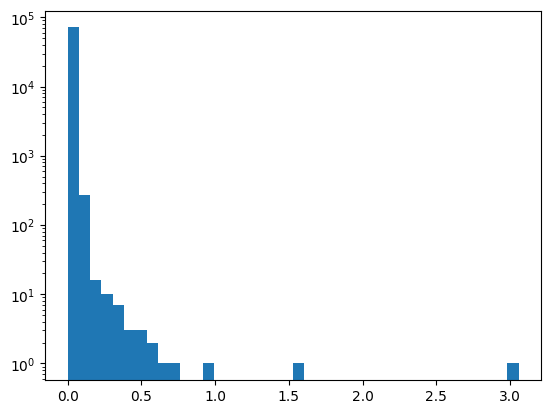

In [11]:
plt.hist(rsgcat['chimin'], bins=40);
plt.yscale('log')

In [12]:
rsgcat = pd.read_csv('data/dolphot/ngc5643/ngc5643_sil_rsgcat_test.csv')
rsgcat = rsgcat[rsgcat['teff_chisq'] < 4700]

In [55]:
chi_all = rsgcat['chimin'].values

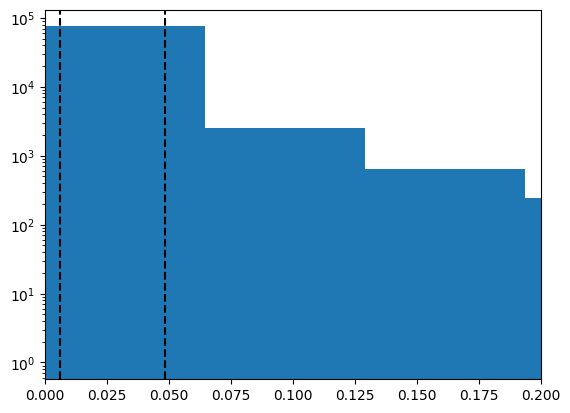

In [56]:
plt.hist(chi_all, bins=100)
plt.yscale('log')
plt.xlim(0.0, 0.2)
sig = np.std(chi_all, ddof=1)
me = np.median(chi_all)
plt.axvline(sig, ls='--', color='black')
plt.axvline(me, ls='--', color='black')

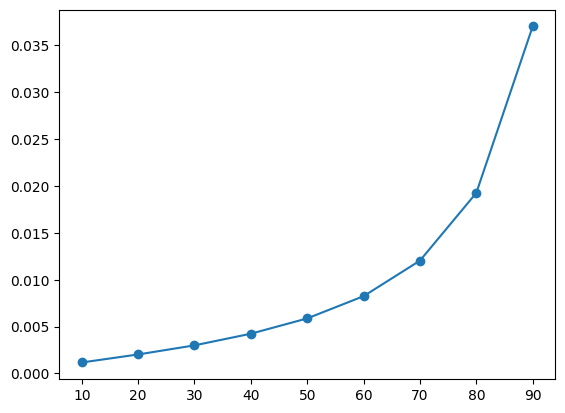

In [57]:
p_ = np.arange(10, 100, 10)
pval = [np.percentile(chi_all, i) for i in p_]
plt.plot(p_, pval, marker='o')

In [58]:
np.percentile(chi_all, 84)

np.float64(0.024242142032157077)

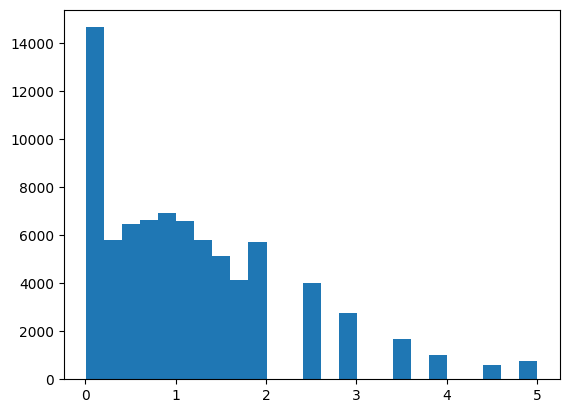

In [59]:
plt.hist(rsgcat['tau_chisq'], bins = 25);

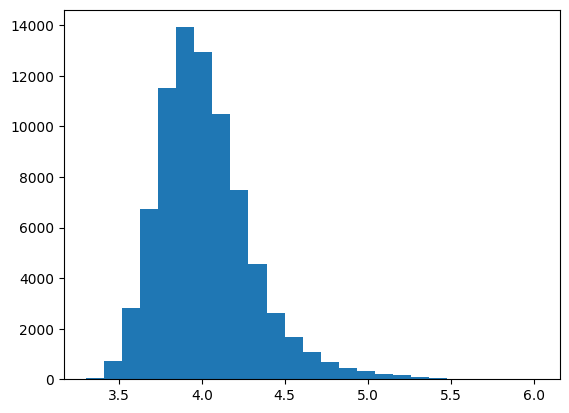

In [60]:
plt.hist(np.log10(rsgcat['lum_chisq']), bins = 25);

In [9]:
cm = rsgcat['chimin'] < np.percentile(rsgcat['chimin'], 50) #0.008
tm = (rsgcat['teff_chisq'] > 2600) & (rsgcat['teff_chisq'] < 4700)
tum = (rsgcat['tau_chisq'].values > 1) & (rsgcat['teff_chisq'] > 3000)
lm = (np.log10(rsgcat['lum_chisq'].values) > 4.0) & (rsgcat['teff_chisq'] < 4500)
netmask = cm & (tm | tum | lm) 
# netmask = cm & tm
netmask.sum()

np.int64(34429)

In [10]:
(cm & tm).sum()

np.int64(33595)

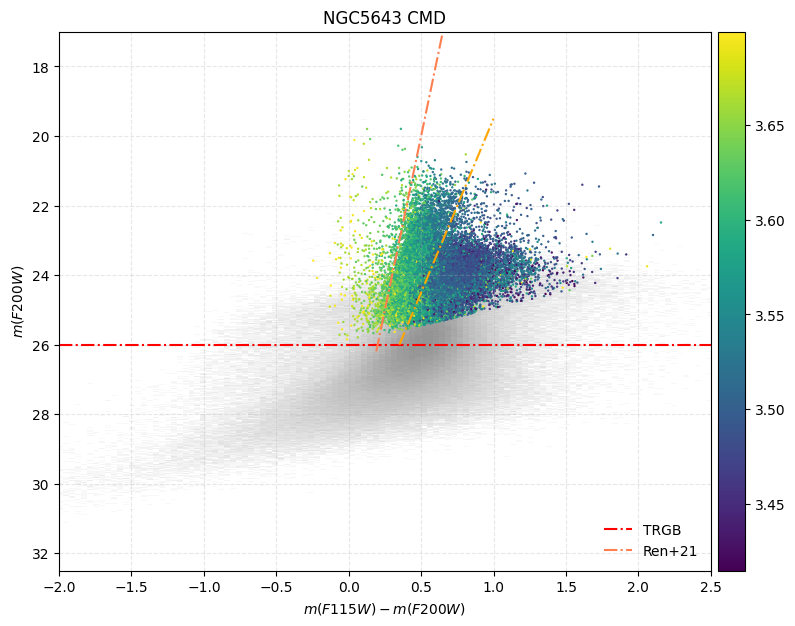

In [11]:
def lin(x, m, c): return m*x+c

fig, ax = plt.subplots(1, 1, figsize = (10, 7))
f1, f2 = 'F115W', 'F200W'

cl, m = cat[f1+'_mag'] - cat[f2+'_mag'], cat[f2+'_mag']
rsg_cl, rsg_m = rsgcat[netmask][f1+'_mag'] - rsgcat[netmask][f2+'_mag'], rsgcat[netmask][f2+'_mag']

ax.hist2d(cl, m, bins = 4000, norm = 'log', cmap = 'Grays')
sc = ax.scatter(rsg_cl, rsg_m, c=np.log10(rsgcat[netmask]['teff_chisq']), cmap = 'viridis', s=.5)

ax.axhline(26, color = 'red', label='TRGB', linestyle = '-.')
ax.plot(np.linspace(0.1905, 1, 100), lin(np.linspace(0.1905, 1, 100), -20.0, 33.0-3), linestyle='-.', color = 'coral', label = 'Ren+21')
ax.plot(np.linspace(0.35, 1, 100), lin(np.linspace(0.35, 1, 100), -10.0, 25+4.5), linestyle='-.', color = 'orange')

cbar = fig.colorbar(sc, ax = ax, pad = 0.009)
ax.set_xlabel(rf'$m({f1}) - m({f2})$')
ax.set_ylabel(rf'$m({f2})$')
ax.set_title('NGC5643 CMD')

ax.legend(loc = 'lower right', framealpha = 0)
ax.tick_params(axis='both', which='major')
ax.tick_params(axis='both', which='minor')
cbar.ax.tick_params() 
ax.grid(alpha = 0.3, linestyle = '--')
ax.set_xlim(-2, 2.5)
# ax.set_xlim(0, 1)
ax.set_ylim(32.5, 17)
# ax.set_ylim(26, 20)
plt.show()

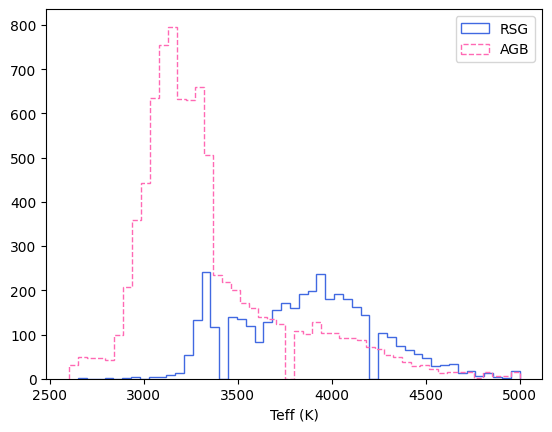

In [ ]:
m1 = (rsgcat[netmask]['F115W_mag'] > 10) & (rsgcat[netmask]['F115W_mag'] < 32)  & (rsgcat[netmask]['F200W_mag'] > 10) & (rsgcat[netmask]['F200W_mag'] < 32)
cl1 = rsgcat[netmask][m1]['F115W_mag'] - rsgcat[netmask][m1]['F200W_mag']
cm1 = rsgcat[netmask][m1]['F200W_mag']
m2 = cm1 > lin(cl1, -20.0, 33.0-3)
m3 = cm1 < lin(cl1, -10.0, 25+4.5)

rsg_lit = rsgcat[netmask][m1][m2&m3]
csm1 = (rsg_lit['chimin'] < np.percentile(rsgcat[netmask]['chimin'], 50)) #& (np.log10(rsg_lit['lum_chisq']) > 4.2) # & (rsg_lit['teff_chisq'] == 4200)
agb_lit = rsgcat[netmask][m1][m2&~m3]
csm2 = (agb_lit['chimin'] < np.percentile(rsgcat[netmask]['chimin'], 50)) #& (np.log10(agb_lit['lum_chisq']) > 4.2) # & (agb_lit['teff_chisq'] == 4200)
plt.hist(rsg_lit[csm1]['teff_chisq'], bins=50, histtype='step', label = 'RSG', lw=2, color='royalblue', density=False)
plt.hist(agb_lit[csm2]['teff_chisq'], bins=50, histtype='step', label = 'AGB', lw=2, linestyle='--', color='hotpink', density=False)
# plt.ylim(0, 2000)
plt.xlabel('Teff (K)')
plt.legend(); 
# plt.savefig('plots/ngc543_rsg_line_lc.png', dpi=300, bbox_inches='tight');

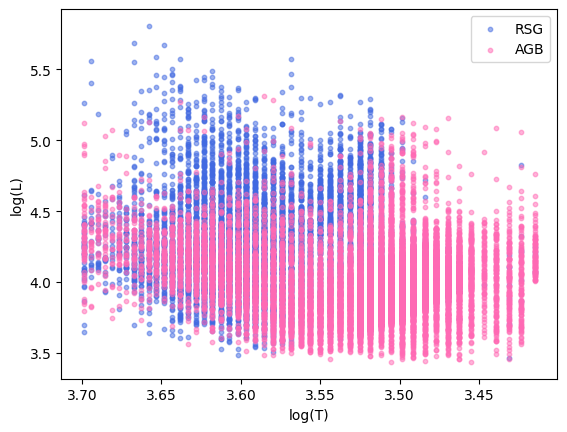

In [13]:
plt.scatter(np.log10(rsg_lit['teff_chisq']), np.log10(rsg_lit['lum_chisq']), s=10, alpha=0.5, color='royalblue', label='RSG')
plt.scatter(np.log10(agb_lit['teff_chisq']), np.log10(agb_lit['lum_chisq']), s=10, alpha=0.5, color='hotpink', label='AGB')
plt.gca().invert_xaxis()
plt.legend()
# plt.xlim(6, 3)
plt.xlabel('log(T)')
plt.ylabel('log(L)');

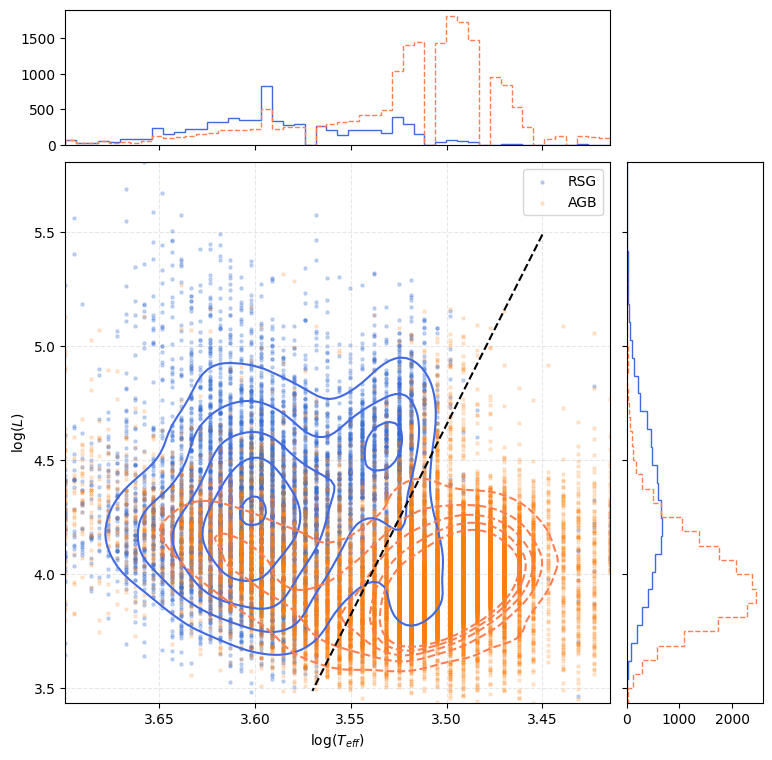

In [16]:
def fmt(x):
    s = f"{x:.1f}"
    if s.endswith("0"):
        s = f"{x:.0f}"
    return rf"{s} \%" if plt.rcParams["text.usetex"] else f"{s} %"

fig, axs = plt.subplot_mosaic([['hist_teff', '.'],
                               ['contour', 'hist_lum']],
                              figsize=(9, 9),
                              width_ratios=(4, 1), height_ratios=(1, 4),
                              layout='tight', sharex=False, sharey=False, 
                              gridspec_kw={"hspace": 0.05, "wspace": 0.05})

axs['hist_teff'].sharex(axs['contour'])
axs['hist_lum'].sharey(axs['contour'])

rsg_logT = np.log10(rsg_lit['teff_chisq'])
rsg_logL = np.log10(rsg_lit['lum_chisq'])

agb_logT = np.log10(agb_lit['teff_chisq'])
agb_logL = np.log10(agb_lit['lum_chisq'])

xy_rsg = np.vstack([rsg_logT, rsg_logL])
kde_rsg = gaussian_kde(xy_rsg)
x_rsg, y_rsg = np.mgrid[rsg_logT.min():rsg_logT.max():100j, rsg_logL.min():rsg_logL.max():100j]
z_rsg = kde_rsg(np.vstack([x_rsg.ravel(), y_rsg.ravel()])).reshape(x_rsg.shape)
axs['contour'].scatter(rsg_logT, rsg_logL, s=5, marker='o', facecolor=None, edgecolor='royalblue', alpha=0.25, label='RSG')
rsg_cs = axs['contour'].contour(x_rsg, y_rsg, z_rsg, colors='royalblue', linewidths=1.5, linestyles='-', label='RSG', levels=np.linspace(0, 10, 6))
# axs['contour'].clabel(rsg_cs, rsg_cs.levels, fmt=fmt, fontsize=10, colors='black')

xy_agb = np.vstack([agb_logT, agb_logL])
kde_agb = gaussian_kde(xy_agb)
x_agb, y_agb = np.mgrid[agb_logT.min():agb_logT.max():100j, agb_logL.min():agb_logL.max():100j]
z_agb = kde_agb(np.vstack([x_agb.ravel(), y_agb.ravel()])).reshape(x_agb.shape)
axs['contour'].scatter(agb_logT, agb_logL, s=5, marker='x', facecolor=None, edgecolor='coral', alpha=0.25, label='AGB')
agb_cs = axs['contour'].contour(x_agb, y_agb, z_agb, colors='coral', linewidths=1.5, linestyles='--', label='AGB', levels=np.linspace(0, 10, 6))
# axs['contour'].clabel(agb_cs, agb_cs.levels, fmt=fmt, fontsize=10, colors='black')

xs = np.linspace(3.45, 3.57, 100)
ys = lin(xs, -16.67, 63)
axs['contour'].plot(xs, ys, ls='--', color='black')

axs['contour'].set_xlabel(r'$\text{log}(T_{eff})$')
axs['contour'].set_ylabel(r'$\text{log}(L)$')
axs['contour'].legend()
axs['contour'].grid(alpha=0.3, linestyle='--')
axs['contour'].invert_xaxis()

axs['hist_teff'].hist(rsg_logT, bins=50, histtype='step', label = 'RSG', lw=2, color='royalblue', density=False)
axs['hist_teff'].hist(agb_logT, bins=50, histtype='step', label = 'AGB', lw=2, linestyle='--', color='coral', density=False)
axs['hist_teff'].tick_params(axis='x', which='both', labelbottom=False)

axs['hist_lum'].hist(rsg_logL, bins=30, histtype='step', label = 'RSG', lw=2, color='royalblue', density=False, orientation='horizontal')
axs['hist_lum'].hist(agb_logL, bins=30, histtype='step', label = 'AGB', lw=2, linestyle='--', color='coral', density=False, orientation='horizontal')
axs['hist_lum'].tick_params(axis='y', which='both', labelleft=False)

plt.show()

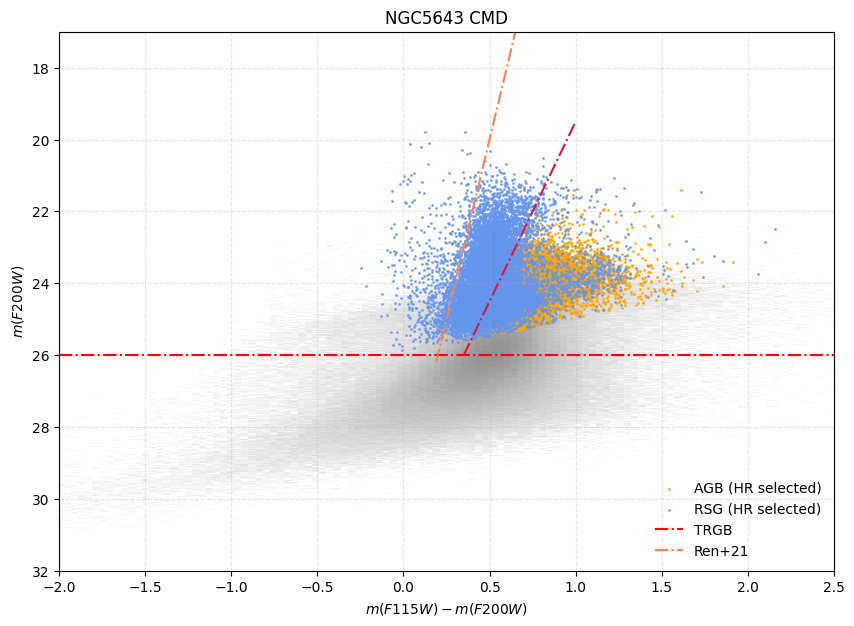

In [15]:
full_logT, full_logL = np.log10(rsgcat[netmask]['teff_chisq']), np.log10(rsgcat[netmask]['lum_chisq'])
hr_mask = full_logL > lin(full_logT, -16.67, 63)
rsg_hr = rsgcat[netmask][hr_mask]
agb_hr = rsgcat[netmask][~hr_mask]

fig, ax = plt.subplots(1, 1, figsize = (10, 7))
f1, f2 = 'F115W', 'F200W'

cl, m = cat[f1+'_mag'] - cat[f2+'_mag'], cat[f2+'_mag']
rsg_cl, rsg_m = rsg_hr[f1+'_mag'] - rsg_hr[f2+'_mag'], rsg_hr[f2+'_mag']
agb_cl, agb_m = agb_hr[f1+'_mag'] - agb_hr[f2+'_mag'], agb_hr[f2+'_mag']

ax.hist2d(cl, m, bins = 4000, norm = 'log', cmap = 'Grays')
ax.scatter(agb_cl, agb_m, color='orange', alpha=0.8, s=1, label='AGB (HR selected)')
ax.scatter(rsg_cl, rsg_m, color='cornflowerblue', alpha=0.8, s=1, label='RSG (HR selected)')
# ax.scatter(agb_cl, agb_m, color='orange', alpha=0.8, s=1, label='AGB (HR selected)')

ax.axhline(26, color = 'red', label='TRGB', linestyle = '-.')
ax.plot(np.linspace(0.1905, 1, 100), lin(np.linspace(0.1905, 1, 100), -20.0, 33.0-3), linestyle='-.', color = 'coral', label = 'Ren+21')
ax.plot(np.linspace(0.35, 1, 100), lin(np.linspace(0.35, 1, 100), -10.0, 25+4.5), linestyle='-.', color = 'crimson')

ax.set_xlabel(rf'$m({f1}) - m({f2})$')
ax.set_ylabel(rf'$m({f2})$')
ax.set_title('NGC5643 CMD')

ax.legend(loc = 'lower right', framealpha = 0)
ax.tick_params(axis='both', which='major')
ax.tick_params(axis='both', which='minor')
cbar.ax.tick_params() 
ax.grid(alpha = 0.3, linestyle = '--')
ax.set_xlim(-2, 2.5)
# ax.set_xlim(0, 1)
ax.set_ylim(32, 17)
# ax.set_ylim(26, 20)
plt.show()

In [138]:
(np.log10(rsg_hr['lum_chisq']) > 4.2).sum(), len(rsg_hr)

(np.int64(7073), 7073)

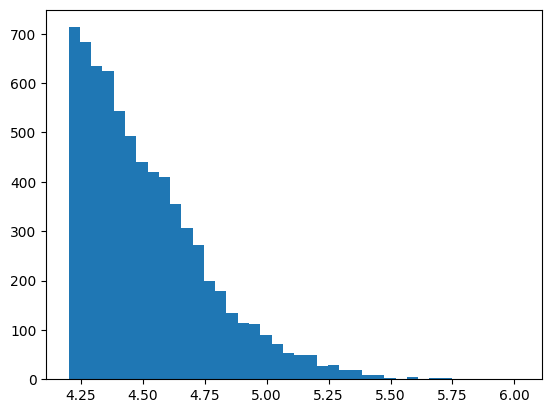

In [139]:
plt.hist(np.log10(rsg_hr['lum_chisq']), bins=40);

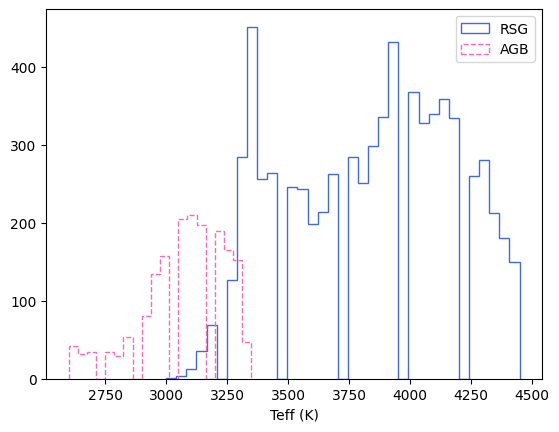

In [140]:
plt.hist(rsg_hr['teff_chisq'], bins=35, histtype='step', label = 'RSG', lw=2, color='royalblue', density=False)
plt.hist(agb_hr['teff_chisq'], bins=20, histtype='step', label = 'AGB', lw=2, linestyle='--', color='hotpink', density=False)
# plt.ylim(0, 2000)
plt.xlabel('Teff (K)')
plt.legend();
# plt.savefig('plots/ngc543_rsg_line_lc.png', dpi=300, bbox_inches='tight');

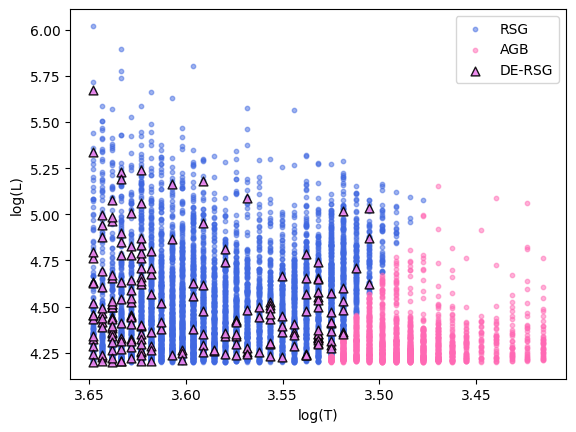

In [141]:
de_rsg = (rsg_hr['tau_chisq'] > 3)
plt.scatter(np.log10(rsg_hr['teff_chisq']), np.log10(rsg_hr['lum_chisq']), s=10, alpha=0.5, color='royalblue', label='RSG')
plt.scatter(np.log10(agb_hr['teff_chisq']), np.log10(agb_hr['lum_chisq']), s=10, alpha=0.5, color='hotpink', label='AGB')
plt.scatter(np.log10(rsg_hr[de_rsg]['teff_chisq']), np.log10(rsg_hr[de_rsg]['lum_chisq']), s=40, marker='^',
            alpha=0.9, fc='violet', ec='black', label='DE-RSG')
plt.gca().invert_xaxis()
plt.legend()
# plt.xlim(6, 3)
plt.xlabel('log(T)')
plt.ylabel('log(L)');

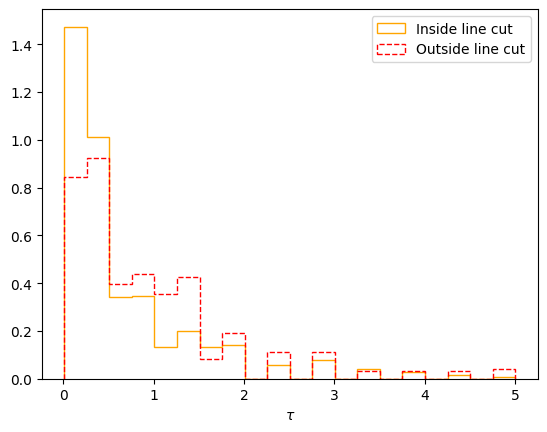

In [47]:
jk = (rsg_hr['F115W_mag'] - rsg_hr['F200W_mag']).values
k = rsg_hr['F200W_mag']
dm = (jk > -10) & (jk < 10) & (k > 10) & (k < 32)
lm = k > lin(jk, -10.0, 25+4.5)

plt.hist(rsg_hr['tau_chisq'][dm&~lm], bins=20, histtype='step', color='orange', label='Inside line cut', linestyle='-', lw=2, density=True)
plt.hist(rsg_hr['tau_chisq'][dm&lm], bins=20, histtype='step', color='red', label='Outside line cut', linestyle='--', lw=2, density=True)
plt.xlabel(r'$\tau$')
plt.legend();

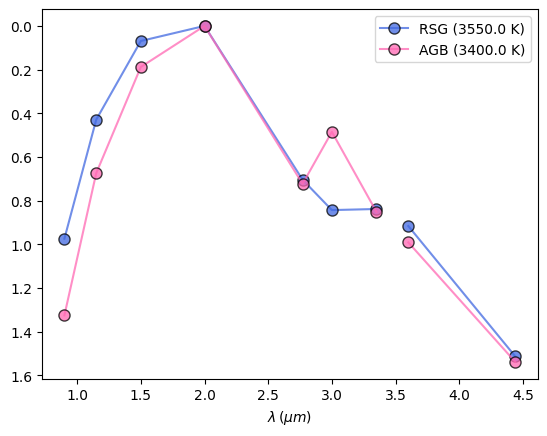

In [159]:
rls = rsg_lit[csm1].replace(99.999, np.nan).sample(1).iloc[0]
als = agb_lit[csm2].replace(99.999, np.nan).sample(1).iloc[0]
nwm = np.array(['N' in i for i in sedfit.cols['magcols']])
v1, v2 = np.nanmin(rls[sedfit.cols['magcols']].values[~nwm]), np.nanmin(als[sedfit.cols['magcols']].values[~nwm])
plt.plot(sedfit.cols['cat_wv'][~nwm], rls[sedfit.cols['magcols']].values[~nwm]-v1, marker='o', markersize=8, markeredgecolor='black', color='royalblue', label=f'RSG ({rls['teff_chisq']} K)', alpha=0.75)
plt.plot(sedfit.cols['cat_wv'][~nwm], als[sedfit.cols['magcols']].values[~nwm]-v2, marker='o', markersize=8, markeredgecolor='black', color='hotpink', label=f'AGB ({als['teff_chisq']} K)', alpha=0.75)
plt.legend()
plt.xlabel(r'$\lambda\,(\mu m)$')
plt.gca().invert_yaxis()

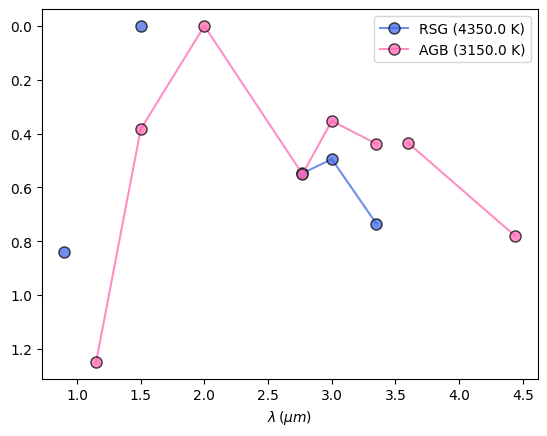

In [235]:
rls = rsg_hr.replace(99.999, np.nan).sample(1).iloc[0]
als = agb_hr.replace(99.999, np.nan).sample(1).iloc[0]
nwm = np.array(['N' in i for i in sedfit.cols['magcols']])
v1, v2 = np.nanmin(rls[sedfit.cols['magcols']].values[~nwm]), np.nanmin(als[sedfit.cols['magcols']].values[~nwm])
plt.plot(sedfit.cols['cat_wv'][~nwm], rls[sedfit.cols['magcols']].values[~nwm]-v1, marker='o', markersize=8, markeredgecolor='black', color='royalblue', label=f'RSG ({rls['teff_chisq']} K)', alpha=0.75)
plt.plot(sedfit.cols['cat_wv'][~nwm], als[sedfit.cols['magcols']].values[~nwm]-v2, marker='o', markersize=8, markeredgecolor='black', color='hotpink', label=f'AGB ({als['teff_chisq']} K)', alpha=0.75)
plt.legend()
plt.xlabel(r'$\lambda\,(\mu m)$')
plt.gca().invert_yaxis()

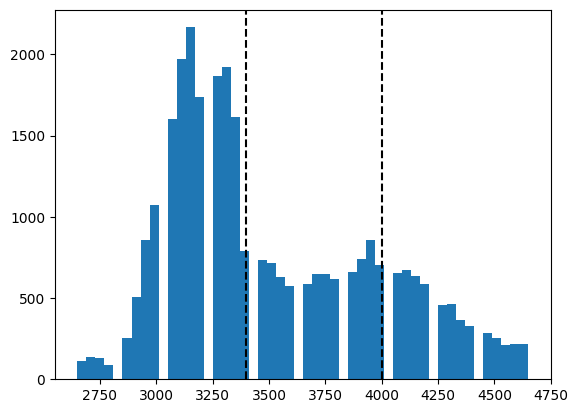

In [104]:
plt.hist(rsgcat[netmask]['teff_chisq'], bins=50)
plt.axvline(3400, ls='--', color='black')
plt.axvline(4000, ls='--', color='black');

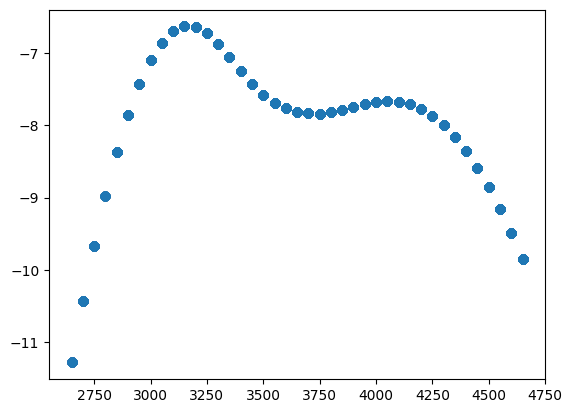

In [174]:
from sklearn import mixture
X_train = rsgcat[netmask]['teff_chisq'].values.reshape(-1, 1)
clf = mixture.GaussianMixture(n_components=3, covariance_type="full")
clf.fit(X_train)
plt.scatter(rsgcat[netmask]['teff_chisq'].values, clf.score_samples(rsgcat[netmask]['teff_chisq'].values.reshape(-1, 1)));

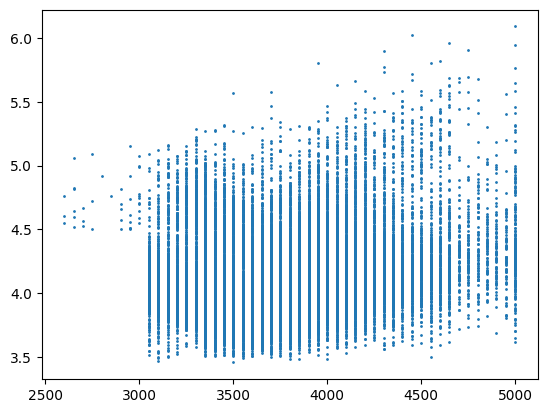

In [48]:
plt.scatter(rsgcat[netmask]['teff_chisq'], np.log10(rsgcat[netmask]['lum_chisq']), s=1);

### parallel mcmc

In [34]:
%reload_ext autoreload
%autoreload 2
from mc_parallel import parallel_sed_fit

In [35]:
#create grf modeldf
sedfit = parallel_sed_fit(gal='ngc5643', 
                          photfile_path='data/dolphot/ngc5643', 
                          dm=30.57, 
                          dmerr=0.06, 
                          z=-0.25, 
                          trgb=('F090W', 26.20),
                          comp='sil',
                          keep_narrow=False, 
                          ncores=1,
                          agbcut=False)
sedfit.apply_initial_cuts()

DOLPHOT catalog contains 1804516 objects after photometry cuts
DOLPHOT catalog contains 1804516 objects after photometry cuts
rsg_sedfit [@ Tue, 09 Sep 2025 22:22:21] [l 106] - INFO - DOLPHOT catalog contains 1804516 objects after photometry cuts
rsg_sedfit [@ Tue, 09 Sep 2025 22:22:21] [l 4] - INFO - WARNING: AGB cut set to False
Applying ndet cuts
Applying ndet cuts
rsg_sedfit [@ Tue, 09 Sep 2025 22:22:21] [l 162] - INFO - Applying ndet cuts
RSG catalog contains 91768 objects after ndet cuts
RSG catalog contains 91768 objects after ndet cuts
rsg_sedfit [@ Tue, 09 Sep 2025 22:22:35] [l 195] - INFO - RSG catalog contains 91768 objects after ndet cuts
Applying chisq cuts
Applying chisq cuts
rsg_sedfit [@ Tue, 09 Sep 2025 22:22:36] [l 4] - INFO - Applying chisq cuts
100%|██████████| 91768/91768 [16:47<00:00, 91.08it/s] 
RSG catalog contains 91768 objects after chisq cuts
RSG catalog contains 91768 objects after chisq cuts
rsg_sedfit [@ Tue, 09 Sep 2025 22:39:23] [l 29] - INFO - RSG catal

,index,X,Y,SNR,Sharpness,Crowding,Type,F090W_mag,F115W_mag,F150W_mag,...,F356W_err,F360M_err,F405N_err,F444W_err,chimin,teff_chisq,tdust_chisq,tau_chisq,av_chisq,lum_chisq
225097,225097,784.54,1466.41,3547.7,-0.024,0.006,1,20.271,19.899,19.690,...,0.001,0.003,0.010,0.003,0.000280,4800.0,500.0,0.5075,1.50,1.389087e+06
225098,225098,755.88,834.86,3471.4,-0.013,0.029,1,20.232,19.923,19.691,...,0.001,0.003,0.011,0.003,0.000906,4450.0,400.0,1.0050,0.50,1.049498e+06
225099,225099,1583.79,2029.10,1712.7,0.005,0.037,1,99.999,19.986,19.787,...,0.001,9.999,9.999,9.999,0.000188,4300.0,200.0,0.7065,0.00,7.907785e+05
225102,225102,1349.44,2206.38,1944.4,-0.013,0.017,1,99.999,19.761,19.676,...,0.001,0.004,0.017,0.005,0.000448,5000.0,400.0,0.1095,0.50,1.192807e+06
225104,225104,17.34,749.93,2704.8,-0.024,0.006,1,20.478,20.235,19.980,...,0.001,0.003,0.013,0.004,0.001801,4650.0,200.0,2.5000,0.00,9.778503e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1725349,1725349,2773.78,1910.56,64.2,-0.019,0.324,1,99.999,25.997,25.247,...,0.024,0.098,1.268,0.278,0.020217,3200.0,200.0,0.4080,0.25,2.957173e+03
1725811,1725811,2234.52,1849.54,59.4,-0.110,0.544,1,99.999,25.964,25.513,...,0.029,9.999,9.999,9.999,0.000022,2850.0,1000.0,0.6070,0.00,2.557667e+03
1725877,1725877,2749.22,1879.19,64.7,-0.031,0.200,1,99.999,26.003,25.695,...,0.025,0.097,0.323,0.162,0.008465,2900.0,1600.0,0.6070,0.00,2.485191e+03
1726050,1726050,2801.00,1935.63,63.4,-0.019,0.363,1,99.999,25.880,25.541,...,0.026,0.100,9.999,0.392,0.067414,3350.0,200.0,0.0100,0.00,2.647131e+03


In [ ]:
#test rsgcat with  10-50 entries
rsgcat = pd.read_csv('data/dolphot/ngc5643/rsgcat_chimin.csv')
testcat = rsgcat[:50]
testcat.reset_index(inplace=True, drop=True)
testcat.loc[:, 'index'] = testcat.index

In [ ]:
#test parallelization
sedfit = parallel_sed_fit(gal='ngc5643', 
                          photfile_path='data/dolphot/ngc5643', 
                          dm=30.57, 
                          dmerr=0.06, 
                          z=-0.25, 
                          trgb=('F090W', 26.20), 
                          keep_narrow=False, 
                          ncores=8,
                          rsgcat=testcat)

In [70]:
sedfit.run_sed_fit()

rsg_sedfit [@ Wed, 27 Aug 2025 14:43:06] [l 16] - INFO - Starting MCMC
Starting MCMC


[Wed, 27 Aug 2025 14:43:07] Running MCMC on index 0
[Wed, 27 Aug 2025 14:43:08] Running MCMC on index 1
[Wed, 27 Aug 2025 14:43:09] Running MCMC on index 2
[Wed, 27 Aug 2025 14:43:09] Running MCMC on index 3
[Wed, 27 Aug 2025 14:43:10] Running MCMC on index 4
[Wed, 27 Aug 2025 14:43:10] Running MCMC on index 5
[Wed, 27 Aug 2025 14:43:11] Running MCMC on index 6
[Wed, 27 Aug 2025 14:43:12] Running MCMC on index 7
[Wed, 27 Aug 2025 14:43:13] Running MCMC on index 8
[Wed, 27 Aug 2025 14:43:14] Running MCMC on index 9
[Wed, 27 Aug 2025 14:43:15] Running MCMC on index 10
[Wed, 27 Aug 2025 14:43:16] Running MCMC on index 11
[Wed, 27 Aug 2025 14:43:17] Running MCMC on index 12
[Wed, 27 Aug 2025 14:43:18] Running MCMC on index 13
[Wed, 27 Aug 2025 14:43:19] Running MCMC on index 14
[Wed, 27 Aug 2025 14:43:19] Running MCMC on index 15
[Wed, 27 Aug 2025 14:43:36] Running MCMC on index 16
[Wed, 27 Aug 2025 14:44:14] Running MCMC on index 17
[Wed, 27 Aug 2025 14:44:18] Running MCMC on index 18
[We

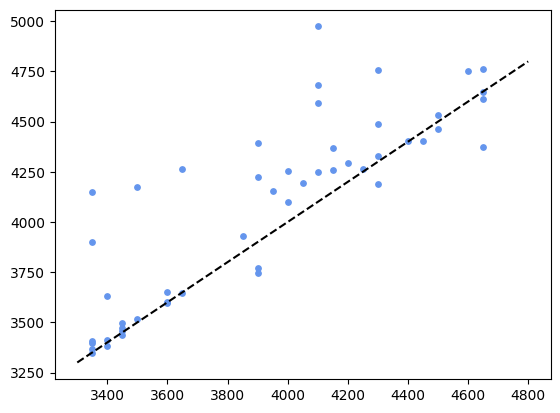

In [ ]:
#compare mcmc teff and chimin teff
plt.scatter(sedfit.rsgcat['teff'], sedfit.rsgcat['temperature_best'], marker='o', color='cornflowerblue', s=15)
plt.plot([3300, 4800], [3300, 4800], ls='--', color='black');